In [321]:
#Import libraries
import requests
import pandas as pd
import requests
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.impute import KNNImputer

#Data Load

## FEMA data

### Housing Assistance Program Data - Owners

https://www.fema.gov/openfema-data-page/housing-assistance-program-data-owners-v2

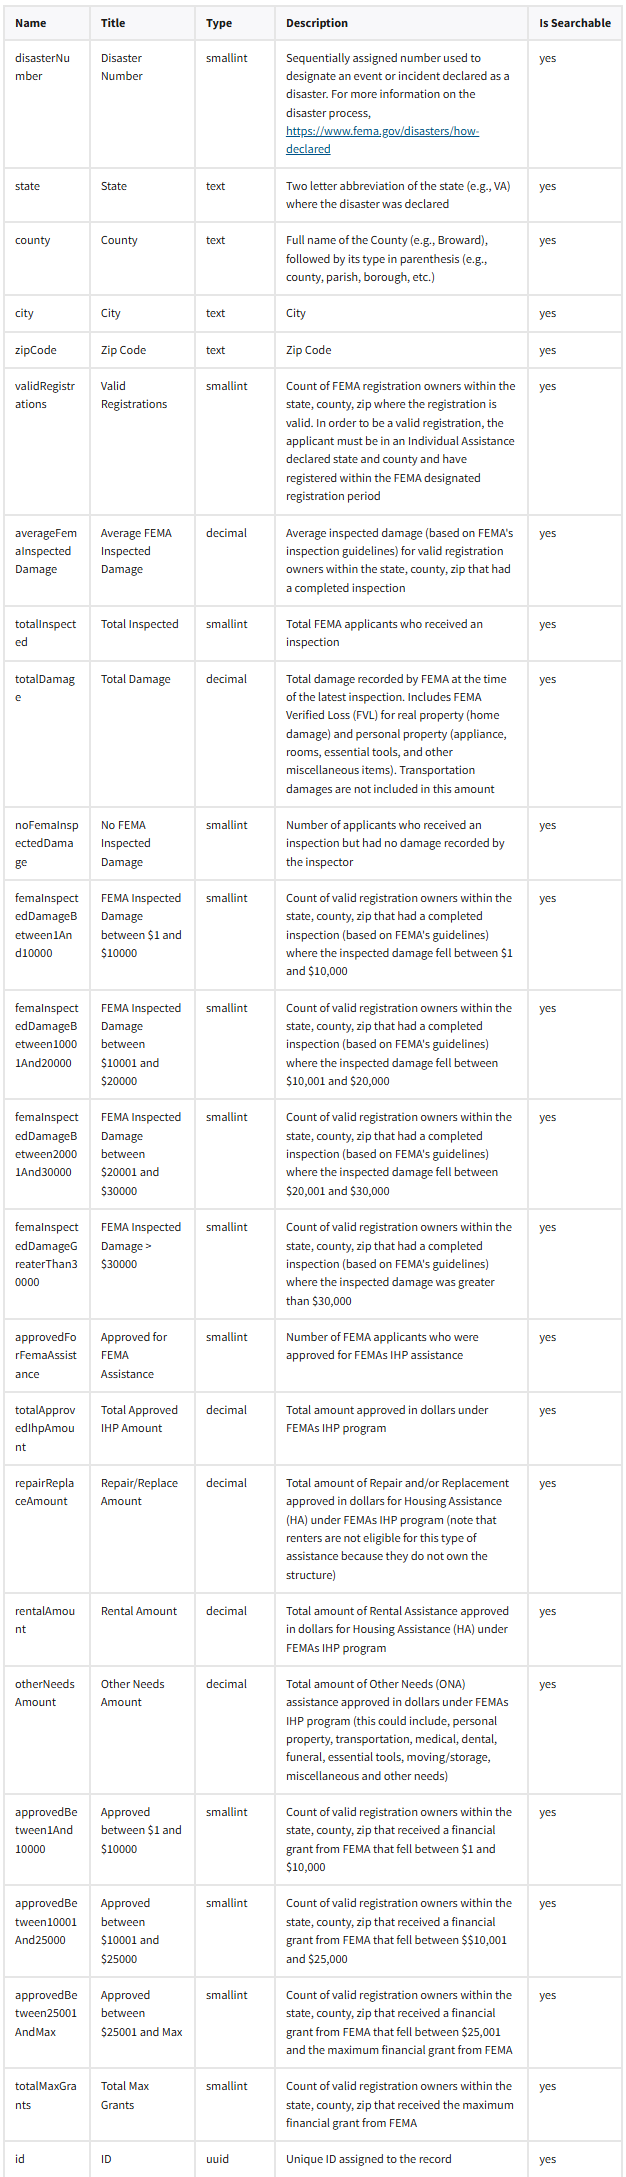

### Housing Assistance Program Data - Renters

https://www.fema.gov/openfema-data-page/housing-assistance-program-data-renters-v2

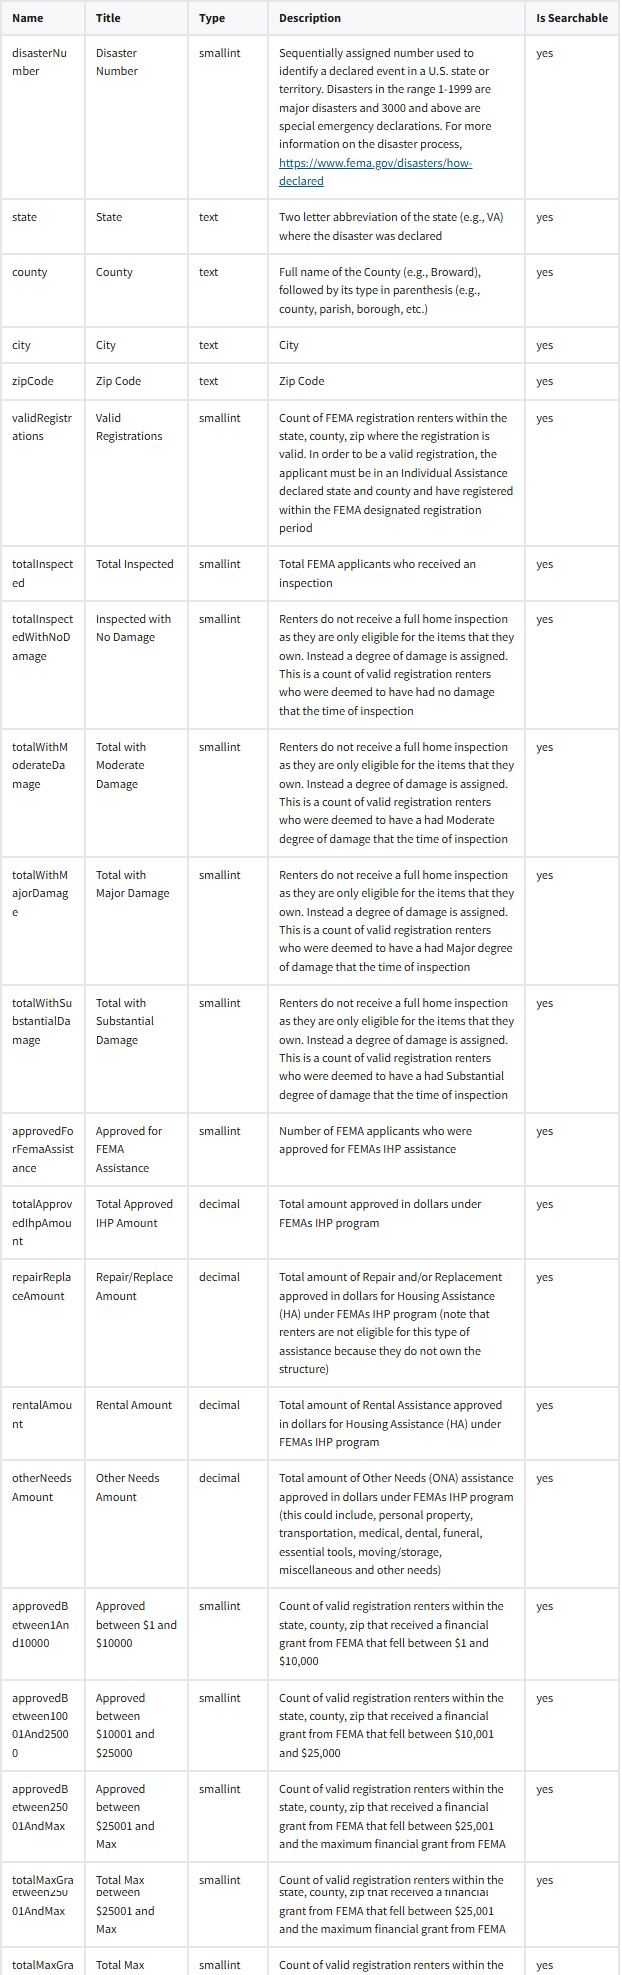

### Registration Intake and Individuals Household Program (RI-IHP)

https://www.fema.gov/openfema-data-page/registration-intake-and-individuals-household-program-ri-ihp-v2

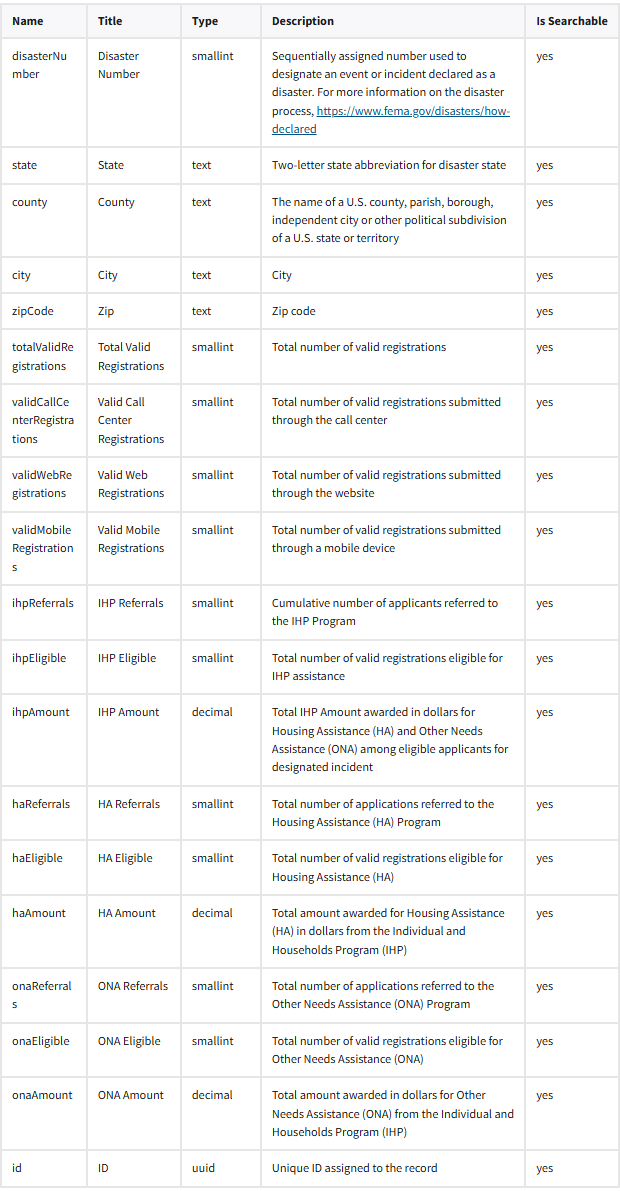

In [ ]:
def fetch_fema_data(base_url, disaster_number, state_code="TX"):
    """
    Fetches data from a FEMA v2 endpoint (Owners, Renters, or RegistrationIntakeIndividualsHouseholdPrograms)
    filtered by disasterNumber and state. Paginates in chunks of up to 10,000 records.

    Parameters
    ----------
    base_url : str
        One of:
            - "https://www.fema.gov/api/open/v2/HousingAssistanceOwners"
            - "https://www.fema.gov/api/open/v2/HousingAssistanceRenters"
            - "https://www.fema.gov/api/open/v2/RegistrationIntakeIndividualsHouseholdPrograms"
    disaster_number : int
        The numeric disaster code, e.g. 4332 for Hurricane Harvey.
    state_code : str
        2-letter state abbreviation, default is "TX".

    Returns
    -------
    list of dict
        All records returned by the API matching the filter criteria.
    """

    top = 10000  #max records per request
    skip = 0
    all_records = []

    #Filter string for state and disaster
    filter_condition = f"disasterNumber eq {disaster_number} and state eq '{state_code}'"

    while True:
        params = {
            "$format": "json",
            "$top": top,
            "$skip": skip,
            "$filter": filter_condition
        }
        response = requests.get(base_url, params=params)
        response.raise_for_status()

        json_data = response.json()

        #JSON key is different, depending on endpoint
        if 'HousingAssistanceOwners' in json_data:
            records = json_data['HousingAssistanceOwners']
        elif 'HousingAssistanceRenters' in json_data:
            records = json_data['HousingAssistanceRenters']
        elif 'RegistrationIntakeIndividualsHouseholdPrograms' in json_data:
            records = json_data['RegistrationIntakeIndividualsHouseholdPrograms']
        else:
            raise RuntimeError(
                "Could not find an expected dataset key in response."
            )

        if not records:
            #No more records left
            break

        all_records.extend(records)
        skip += top  #Move to next 'page'

    return all_records

def records_to_dataframe(records):
    """Converts a list of dicts into a pandas DataFrame."""
    if not records:
        return pd.DataFrame()
    return pd.DataFrame(records)

def main():
    #FEMA v2 endpoints
    owners_url = 'https://www.fema.gov/api/open/v2/HousingAssistanceOwners'
    renters_url = 'https://www.fema.gov/api/open/v2/HousingAssistanceRenters'
    regint_url = 'https://www.fema.gov/api/open/v2/RegistrationIntakeIndividualsHouseholdPrograms'

    #Hurricane Harvey
    disaster_number = 4332
    state_code = 'TX'

    print("Fetching HousingAssistanceOwners data for TX (Harvey 4332)...")
    owners_records = fetch_fema_data(owners_url, disaster_number, state_code)
    print(f"  => Fetched {len(owners_records)} records.\n")

    print("Fetching HousingAssistanceRenters data for TX (Harvey 4332)...")
    renters_records = fetch_fema_data(renters_url, disaster_number, state_code)
    print(f"  => Fetched {len(renters_records)} records.\n")

    print("Fetching RegistrationIntakeIndividualsHouseholdPrograms data for TX (Harvey 4332)...")
    regint_records = fetch_fema_data(regint_url, disaster_number, state_code)
    print(f"  => Fetched {len(regint_records)} records.\n")

    #Convert to a DataFrame
    owners_df = records_to_dataframe(owners_records)
    renters_df = records_to_dataframe(renters_records)
    regint_df = records_to_dataframe(regint_records)

    #Print first few rows
    print("=== Owners (head) ===")
    print(owners_df.head(), "\n")

    print("=== Renters (head) ===")
    print(renters_df.head(), "\n")

    print("=== RegistrationIntake (head) ===")
    print(regint_df.head(), "\n")
    return owners_df, renters_df, regint_df

if __name__ == "__main__":
    owners_df, renters_df, regint_df = main()


Fetching HousingAssistanceOwners data for TX (Harvey 4332)...
  => Fetched 1491 records.

Fetching HousingAssistanceRenters data for TX (Harvey 4332)...
  => Fetched 1623 records.

Fetching RegistrationIntakeIndividualsHouseholdPrograms data for TX (Harvey 4332)...
  => Fetched 2296 records.

=== Owners (head) ===
   disasterNumber state            county          city zipCode  \
0            4332    TX  Aransas (County)  ARANSAS PASS   78335   
1            4332    TX  Aransas (County)  ARANSAS PASS   78336   
2            4332    TX  Aransas (County)        AUSTIN   78728   
3            4332    TX  Aransas (County)          AZLE   76020   
4            4332    TX  Aransas (County)       BAYSIDE   78340   

   validRegistrations  averageFemaInspectedDamage  totalInspected  \
0                   3                    11444.25               3   
1                 813                     6700.91             663   
2                   1                        0.00               1   
3    

### Individuals and Households Program - Valid Registrations

https://www.fema.gov/openfema-data-page/individuals-and-households-program-valid-registrations-v1

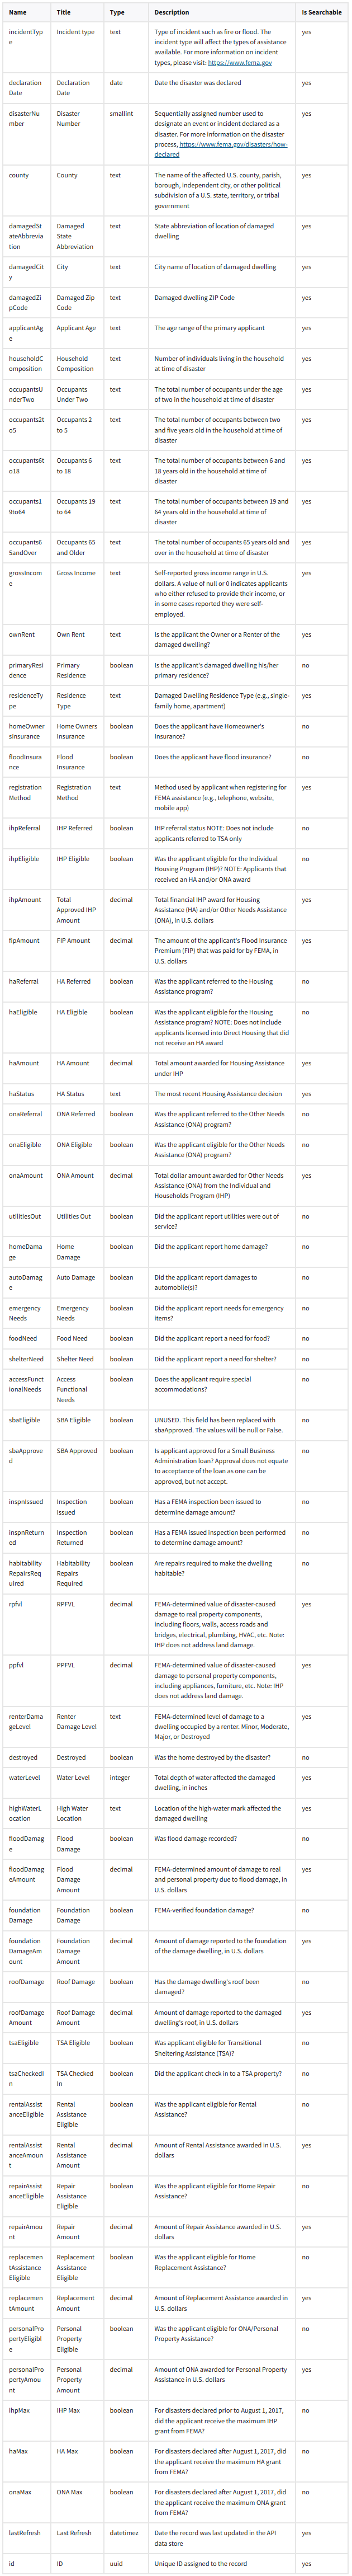

### Individual Assistance Housing Registrants - Large Disasters

https://www.fema.gov/openfema-data-page/individual-assistance-housing-registrants-large-disasters-v1

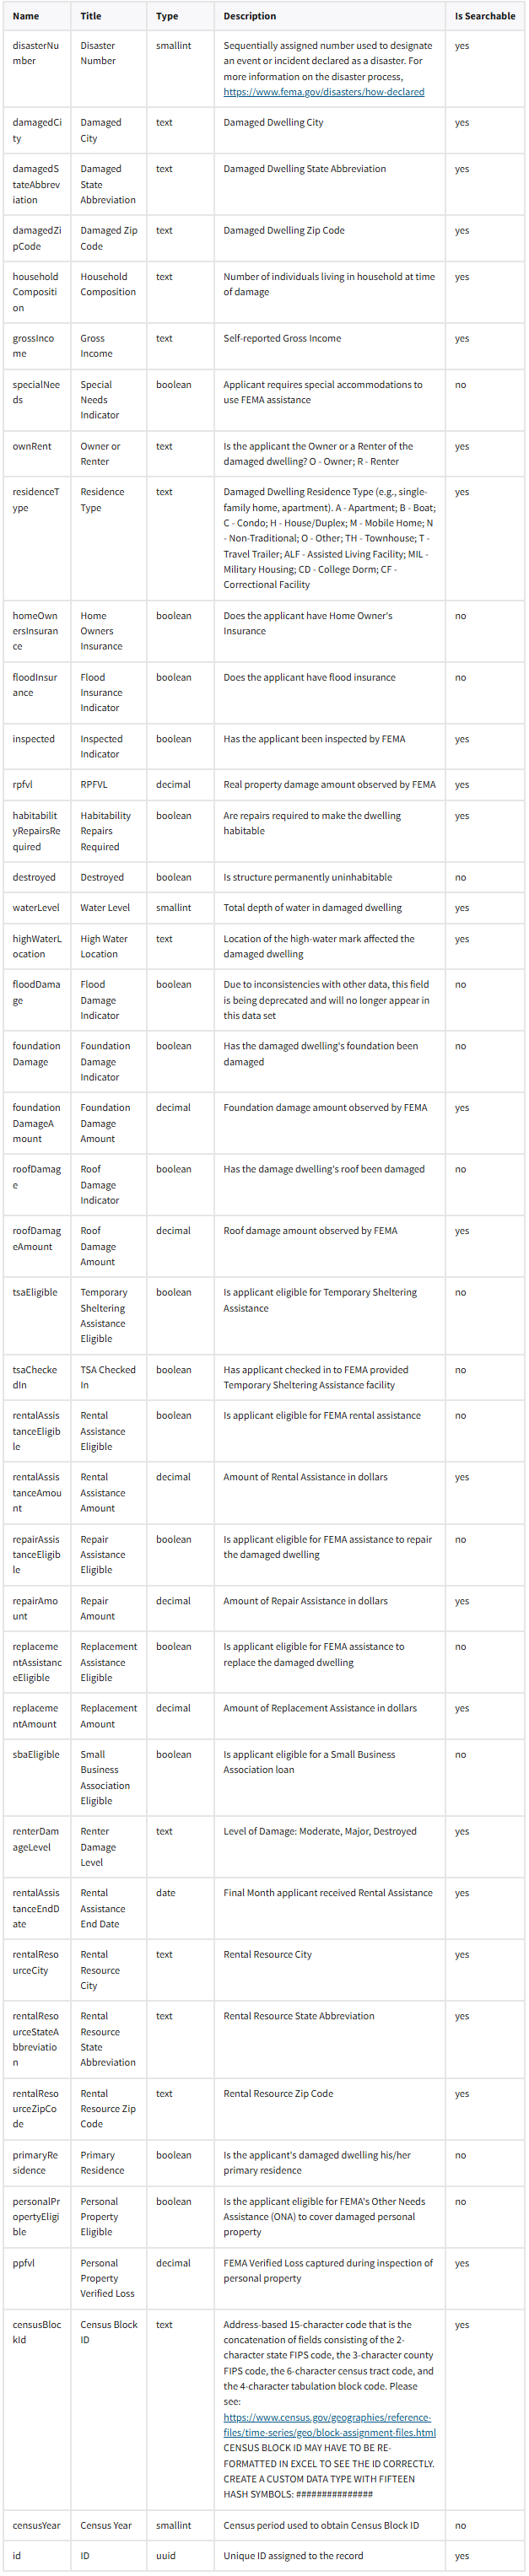

In [ ]:
def fetch_fema_data_v1(base_url, root_key, filter_condition):
    """
    Generic fetch function for OpenFEMA v1 datasets.

    1. Pages through records in chunks of 10,000 (OpenFEMA max).
    2. Applies the specified filter_condition (OData).
    3. Extracts the list of records using the provided root_key.

    Parameters
    ----------
    base_url : str
        e.g., "https://www.fema.gov/api/open/v1/IndividualsAndHouseholdsProgramValidRegistrations"
               or "https://www.fema.gov/api/open/v1/IndividualAssistanceHousingRegistrantsLargeDisasters"
    root_key : str
        The JSON key that contains the data array in the response. For example:
            "IndividualsAndHouseholdsProgramValidRegistrations"
            "IndividualAssistanceHousingRegistrantsLargeDisasters"
    filter_condition : str
        e.g., "disasterNumber eq 4332 and damagedStateAbbreviation eq 'TX'"

    Returns
    -------
    list of dict
        All records retrieved from the API.
    """
    top = 10000   # maximum records to fetch per request
    skip = 0
    all_records = []

    while True:
        params = {
            "$format": "json",
            "$top": top,
            "$skip": skip,
            "$filter": filter_condition
        }
        response = requests.get(base_url, params=params)
        response.raise_for_status()

        data = response.json()
        records = data.get(root_key, [])

        if not records:
            break

        all_records.extend(records)
        skip += top

    return all_records

def records_to_dataframe(records):
    """
    Converts a list of dictionaries into a pandas DataFrame.
    If no records, returns an empty DataFrame.
    """
    if not records:
        return pd.DataFrame()
    return pd.DataFrame(records)

def main():
    #Base URLs and root keys
    valid_registrations_url = ('https://www.fema.gov/api/open/v1/IndividualsAndHouseholdsProgramValidRegistrations')
    valid_registrations_key = 'IndividualsAndHouseholdsProgramValidRegistrations'

    large_disasters_url = ('https://www.fema.gov/api/open/v1/IndividualAssistanceHousingRegistrantsLargeDisasters')
    large_disasters_key = 'IndividualAssistanceHousingRegistrantsLargeDisasters'

    #Filter for Hurricane Harvey (4332) in Texas
    filter_condition = 'disasterNumber eq 4332 and damagedStateAbbreviation eq 'TX''

    #Fetch data from IndividualsAndHouseholdsProgramValidRegistrations
    print("=== Fetching IndividualsAndHouseholdsProgramValidRegistrations (Harvey/TX) ===")
    registrations_records = fetch_fema_data_v1(
        base_url=valid_registrations_url,
        root_key=valid_registrations_key,
        filter_condition=filter_condition
    )
    print(f"Fetched {len(registrations_records)} records.\n")

    #Fetch data from IndividualAssistanceHousingRegistrantsLargeDisasters
    print("=== Fetching IndividualAssistanceHousingRegistrantsLargeDisasters (Harvey/TX) ===")
    large_disasters_records = fetch_fema_data_v1(
        base_url=large_disasters_url,
        root_key=large_disasters_key,
        filter_condition=filter_condition
    )
    print(f"Fetched {len(large_disasters_records)} records.\n")

    #Convert to DataFrame
    registrations_df = records_to_dataframe(registrations_records)
    large_disasters_df = records_to_dataframe(large_disasters_records)

    #Print first few rows
    print("=== Valid Registrations (head) ===")
    print(registrations_df.head(), "\n")

    print("=== Large Disasters ===")
    print(large_disasters_df.head(), "\n")

    return registrations_df, large_disasters_df


if __name__ == "__main__":
    registrations_df, large_disasters_df = main()

=== Fetching IndividualsAndHouseholdsProgramValidRegistrations (Harvey/TX) ===
Fetched 890924 records.

=== Fetching IndividualAssistanceHousingRegistrantsLargeDisasters (Harvey/TX) ===
Fetched 895619 records.

=== Valid Registrations (head) ===
  incidentType           declarationDate  disasterNumber            county  \
0    Hurricane  2017-08-25T00:00:00.000Z            4332   Harris (County)   
1    Hurricane  2017-08-25T00:00:00.000Z            4332   Harris (County)   
2    Hurricane  2017-08-25T00:00:00.000Z            4332   Harris (County)   
3    Hurricane  2017-08-25T00:00:00.000Z            4332   Harris (County)   
4    Hurricane  2017-08-25T00:00:00.000Z            4332  Liberty (County)   

  damagedStateAbbreviation damagedCity damagedZipCode applicantAge  \
0                       TX     HOUSTON          77084        50-64   
1                       TX      SPRING          77379          65+   
2                       TX     HOUSTON          77044        35-49   
3    

# CENSUS Data

https://api.census.gov/data/2017/acs/acs5/variables.html

B19013_001E: Estimate!!Median household income in the past 12 months (in 2017 inflation-adjusted dollars)

B02001_001E: Estimate!!Total	RACE

B02001_002E: Estimate!!Total!!White alone

B17001_001E: Estimate!!Total	POVERTY STATUS IN THE PAST 12 MONTHS BY SEX BY AGE

B17001_002E: Estimate!!Total!!Income in the past 12 months below poverty level

B25003_001E: Estimate!!Total	TENURE

B25003_002E: Estimate!!Total!!Owner occupied	TENURE

In [175]:
#Census API key
CENSUS_API_KEY = "dc84b924e2f677036d67bda27c871b97750e2797"

def fetch_census_acs5_2017_state_level(api_key):
    """
    Fetches ACS 5-year (2017) data at the state level for:
      - Median Income
      - Total Population & White Population (for minority %)
      - Total Population & Below Poverty (for poverty rate)
      - Total Occupied Housing & Owner-Occupied (for ownership rate)

    Returns a list of lists (JSON-style) which we'll parse into a DataFrame.
    """
    #Endpoint, get parameters
    base_url = 'https://api.census.gov/data/2017/acs/acs5'

    #Variables to retrieve
    get_vars = [
        'NAME',
        'B19013_001E',  # Median Household Income
        'B02001_001E',  # Total Population (race)
        'B02001_002E',  # White Alone Population
        'B17001_001E',  # Total Population (poverty)
        'B17001_002E',  # Below Poverty
        'B25003_001E',  # Total Occupied Housing Units
        'B25003_002E',  # Owner Occupied Housing Units
    ]

    #Fetch for Texas, county level
    params = {
        "get": ",".join(get_vars),
        "for": "county:*",
        "in": "state:48",
        "key": api_key
    }


    #Request
    response = requests.get(base_url, params=params)
    response.raise_for_status()

    #Convert JSON response to pythonlist of lists
    data = response.json()
    return data

def create_dataframe_and_calculate(data):
    """
    Takes the raw list-of-lists from the Census API (where first row is headers),
    creates a DataFrame, calculates the derived metrics, and returns a tidy DataFrame.
    """
    #First row in 'data' is the header, subsequent rows are the data
    header = data[0]
    rows = data[1:]

    #Create DataFrame
    df = pd.DataFrame(rows, columns=header)

    #Rename columns for clarity
    df.rename(columns={
        'B19013_001E': 'medianIncome',
        'B02001_001E': 'totalPopRace',
        'B02001_002E': 'whitePop',
        'B17001_001E': 'totalPopPoverty',
        'B17001_002E': 'belowPoverty',
        'B25003_001E': 'totalHouseholds',
        'B25003_002E': 'ownerOccupied'
    }, inplace=True)

    #Convert numeric columns from strings to numeric
    numeric_cols = [
        'medianIncome',
        'totalPopRace',
        'whitePop',
        'totalPopPoverty',
        'belowPoverty',
        'totalHouseholds',
        'ownerOccupied'
    ]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Derived columns
    # Percent Minority
    df['pctMinority'] = ((df['totalPopRace'] - df['whitePop']) / df['totalPopRace'])

    # Poverty Rate
    df['povertyRate'] = (df['belowPoverty'] / df['totalPopPoverty'])

    # Home Ownership Rate
    df['homeOwnershipRate'] = (df['ownerOccupied'] / df['totalHouseholds'])

    return df

def main():
    #Fetch raw data
    raw_data = fetch_census_acs5_2017_state_level(CENSUS_API_KEY)

    #Create DataFrame + compute derived columns
    df = create_dataframe_and_calculate(raw_data)

    #Plot first few rows
    print("=== ACS 5-Year 2017, County-Level, Texas (head) ===")
    print(df.head(10))
    return df

if __name__ == "__main__":
    census_data = main()


=== ACS 5-Year 2017, County-Level, Texas (head) ===
                    NAME  medianIncome  totalPopRace  whitePop  \
0     Polk County, Texas         43267         46974     39589   
1   Castro County, Texas         44643          7891      7309   
2    Irion County, Texas         63021          1592      1312   
3  Kleberg County, Texas         41700         31540     27601   
4  Willacy County, Texas         29104         21839     20950   
5    Cooke County, Texas         60027         39064     35827   
6   Crosby County, Texas         38674          5895      5397   
7   Dawson County, Texas         43201         13095     10239   
8   Fisher County, Texas         45294          3875      3527   
9    Duval County, Texas         35443         11434      9841   

   totalPopPoverty  belowPoverty  totalHouseholds  ownerOccupied state county  \
0            43325          8120            17632          13523    48    373   
1             7742          1232             2462          

## NOAA Storm Events

https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/

cz_type Ex: C, Z , M
Indicates whether the event happened in a (C) county/parish, (Z) zone or (M) marine

cz_name Ex: AIKEN, RICHMOND, BAXTER (County/Parish, Zone or Marine Name
assigned to the county FIPS number or NWS Forecast Zone)
wfo Ex: CAE, BYZ, GJT (National Weather Service Forecast Office’s area of responsibility
(County Warning Area) in which the event occurred)

begin_yearmonth: month, year of when an event started

begin_day: day of when an event started

episode_id Ex: 61280, 62777, 63250
(ID assigned by NWS to denote the storm episode; links the event details file with the location
& fatality files)

event_type Ex: Hail, Thunderstorm Wind, Snow, Ice (spelled out; not abbreviated)

damage_property Ex: 10.00K, 0.00K, 10.00M
The estimated amount of damage to property incurred by the weather event. (e.g. 10.00K =10,000; 10.00M = 10,000,000)

damage_crops Ex: 0.00K, 500.00K, 15.00M
The estimated amount of damage to crops incurred by the weather event (e.g. 10.00K = 10,000; 10.00M = 10,000,000)

In [ ]:
#Storm data
storm_details = pd.read_csv('https://raw.githubusercontent.com/ex-pr/projects/refs/heads/main/research_paper/data/Storm_data/StormEvents_details-ftp_v1.0_d2017_c20250122%20-%20StormEvents_details-ftp_v1.0_d2017_c20250122_Texas.csv')
storm_details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228 entries, 0 to 227
Data columns (total 51 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   BEGIN_YEARMONTH     228 non-null    int64  
 1   BEGIN_DAY           228 non-null    int64  
 2   BEGIN_TIME          228 non-null    int64  
 3   END_YEARMONTH       228 non-null    int64  
 4   END_DAY             228 non-null    int64  
 5   END_TIME            228 non-null    int64  
 6   EPISODE_ID          228 non-null    int64  
 7   EVENT_ID            228 non-null    int64  
 8   STATE               228 non-null    object 
 9   STATE_FIPS          228 non-null    int64  
 10  YEAR                228 non-null    int64  
 11  MONTH_NAME          228 non-null    object 
 12  EVENT_TYPE          228 non-null    object 
 13  CZ_TYPE             228 non-null    object 
 14  CZ_FIPS             228 non-null    int64  
 15  CZ_NAME             228 non-null    object 
 16  WFO     

## FEMA: National Risk Index

https://hazards.fema.gov/nri/data-resources

STATE: State Name

COUNTY: County Name

RISK_VALUE: National Risk Index - Value - Composite

RISK_SCORE: National Risk Index - Score - Composite

RISK_RATNG: National Risk Index - Rating - Composite

SOVI_SCORE: Social Vulnerability - Score

SOVI_RATNG: Social Vulnerability - Rating

RESL_SCORE: Community Resilience - Score

RESL_RATNG: Community Resilience - Rating

RESL_SPCTL: Community Resilience - State Percentile

RESL_VALUE: Community Resilience - Value

CRF_VALUE: Community Risk Factor - Value


In [218]:
#NRI data
nri_df = pd.read_csv('https://raw.githubusercontent.com/ex-pr/projects/refs/heads/main/research_paper/data/NRI_data/NRI_Table_Counties_Texas%20-%20NRI_Table_Counties_Texas_filtered.csv')
nri_df.head()

,STATE,COUNTY,RISK_VALUE,RISK_SCORE,RISK_RATNG,SOVI_SCORE,SOVI_RATNG,RESL_SCORE,RESL_RATNG,RESL_SPCTL,RESL_VALUE,CRF_VALUE
0,Texas,Anderson,1.707405e+07,76.805600,Relatively Low,84.279999,Very High,21.480000,Relatively Low,0.444882,2.481423,1.370186479
1,Texas,Andrews,4.613645e+06,38.975501,Very Low,64.190002,Relatively High,10.790000,Very Low,0.271654,2.422904,1.308992364
2,Texas,Angelina,2.215546e+07,81.673560,Relatively Low,98.889999,Very High,31.950001,Relatively Low,0.594488,2.525665,1.499265329
3,Texas,Aransas,2.630298e+07,84.505250,Relatively Moderate,93.760002,Very High,46.340000,Relatively Moderate,0.811024,2.584145,1.181438352
4,Texas,Archer,2.781837e+06,21.380846,Very Low,23.010000,Relatively Low,28.580000,Relatively Low,0.535433,2.511451,1.119484804


## HUD data

### Comprehensive Housing Affordability Strategy

https://www.huduser.gov/portal/datasets/cp.html

image.png


```
Column Name,Line_Type,Tenure,1 of 4 housing problems,Household income
T11_est1,Total,Total: Occupied housing units,All,All
T11_est2,Subtotal,Owner occupied,All,All
T11_est3,Subtotal,Owner occupied,1 or more of the 4 housing problems,All
T11_est45,Subtotal,Renter occupied,All,All
T11_est46,Subtotal,Renter occupied,1 or more of the 4 housing problems,All
```

In [ ]:
#CHAS data
chas_problems_df = pd.read_csv('https://raw.githubusercontent.com/ex-pr/projects/refs/heads/main/research_paper/data/2013thru2017-050-csv/Table11_Texas.csv')
chas_problems_df.head()

#https://raw.githubusercontent.com/ex-pr/projects/refs/heads/main/research_paper/data/2013thru2017-050-csv/Table12_Texas.csv
#https://raw.githubusercontent.com/ex-pr/projects/refs/heads/main/research_paper/data/2013thru2017-050-csv/Table1_Texas.csv

,source,sumlevel,geoid,name,st,cnty,T11_est1,T11_est2,T11_est3,T11_est4,...,T11_moe78,T11_moe79,T11_moe80,T11_moe81,T11_moe82,T11_moe83,T11_moe84,T11_moe85,T11_moe86,T11_moe87
0,2013thru2017,50,05000US48001,"Anderson County, Texas",48,1,16565,11750,2575,185,...,31,31,31,31,31,31,31,31,31,31
1,2013thru2017,50,05000US48003,"Andrews County, Texas",48,3,5415,3980,640,80,...,21,21,21,21,21,21,21,21,21,21
2,2013thru2017,50,05000US48005,"Angelina County, Texas",48,5,30930,20425,3825,560,...,31,31,31,31,31,31,31,31,31,31
3,2013thru2017,50,05000US48007,"Aransas County, Texas",48,7,9530,7040,1645,260,...,25,25,25,25,25,25,25,25,25,25
4,2013thru2017,50,05000US48009,"Archer County, Texas",48,9,3350,2750,435,35,...,19,19,19,19,19,19,19,19,19,19


image.png
```
Column Name,Line_Type,Tenure,Race/ethnicity,Cost burden
T9_est1,Total,Total: Occupied housing units,All,All
T9_est2,Subtotal,Owner occupied,All,All
T9_est3,Subtotal,Owner occupied,"White alone, non-Hispanic",All
T9_est8,Subtotal,Owner occupied,"Black or African-American alone, non-Hispanic",All
T9_est13,Subtotal,Owner occupied,"Asian alone, non-Hispanic",All
T9_est18,Subtotal,Owner occupied,"American Indian or Alaska Native alone, non-Hispanic",All
T9_est23,Subtotal,Owner occupied,"Pacific Islander alone, non-Hispanic",All
T9_est28,Subtotal,Owner occupied,"Hispanic, any race",All
T9_est33,Subtotal,Owner occupied,"other (including multiple races, non-Hispanic)",All
T9_est38,Subtotal,Renter occupied,All,All
T9_est39,Subtotal,Renter occupied,"White alone, non-Hispanic",All
T9_est44,Subtotal,Renter occupied,"Black or African-American alone, non-Hispanic",All
T9_est49,Subtotal,Renter occupied,"Asian alone, non-Hispanic",All
T9_est54,Subtotal,Renter occupied,"American Indian or Alaska Native alone, non-Hispanic",All
T9_est59,Subtotal,Renter occupied,"Pacific Islander alone, non-Hispanic",All
T9_est64,Subtotal,Renter occupied,"Hispanic, any race",All
T9_est69,Subtotal,Renter occupied,"other (including multiple races, non-Hispanic)",All
```


In [ ]:
#CHAS data
chas_race_df = pd.read_csv('https://raw.githubusercontent.com/ex-pr/projects/refs/heads/main/research_paper/data/2013thru2017-050-csv/Table9_Texas.csv')
chas_race_df.head()

,source,sumlevel,geoid,name,st,cnty,T9_est1,T9_est2,T9_est3,T9_est4,...,T9_moe64,T9_moe65,T9_moe66,T9_moe67,T9_moe68,T9_moe69,T9_moe70,T9_moe71,T9_moe72,T9_moe73
0,2013thru2017,50,05000US48001,"Anderson County, Texas",48,1,16565,11750,9315,7765,...,176,176,61,21,31,59,46,30,24,31
1,2013thru2017,50,05000US48003,"Andrews County, Texas",48,3,5415,3980,1965,1755,...,194,173,65,77,21,57,49,21,18,21
2,2013thru2017,50,05000US48005,"Angelina County, Texas",48,5,30930,20425,15305,13165,...,266,140,163,148,85,94,87,35,20,31
3,2013thru2017,50,05000US48007,"Aransas County, Texas",48,7,9530,7040,5630,4380,...,226,232,142,62,25,34,27,23,13,25
4,2013thru2017,50,05000US48009,"Archer County, Texas",48,9,3350,2750,2590,2215,...,34,27,19,19,19,20,20,19,19,19


### 2013-2017 ACS 5-Year estimates of housing characteristics compiled at the county level.

https://hudgis-hud.opendata.arcgis.com/datasets/fb3a36d3f1364350becadb5c2e12fd71/about

Attribute Label: NAME
Attribute Definition: Name of County

Attribute Label: B25002EST2_PCT
Attribute Definition: Occupied housing units as a %

Attribute Label: B25009EST2_PCT
Attribute Definition: Owner Occupied as a %

Attribute Label: B25009EST10_PCT
Attribute Definition: Renter Occupied as a %

Attribute Label: B25037EST3
Attribute Definition: Median Year Structure Built for Renter Occupied Units

In [ ]:
acs_df = pd.read_csv('https://raw.githubusercontent.com/ex-pr/projects/refs/heads/main/research_paper/data/HUD_data/ACS_5YR_Housing_Estimate_Data_by_County_2352642343660635057_Texas.csv')
acs_df.head()

,OBJECTID_1,GEOID,STATE,STUSAB,STATE_NAME,COUNTY,NAME,B25002EST1,B25002EST2,B25002EST2_PCT,...,B25123EST10,B25123EST10_PCT,B25123EST11,B25123EST11_PCT,B25123EST12,B25123EST12_PCT,B25123EST13,B25123EST13_PCT,Shape__Area,Shape__Length
0,1895,48229,48,TX,Texas,229,Hudspeth,1595,1127,70.66,...,25,8.36,0,0.00,0,0.0,239,79.93,1.632037e+10,606052.1814
1,1896,48231,48,TX,Texas,231,Hunt,38119,33596,88.13,...,453,4.42,7,0.07,0,0.0,5334,52.09,3.265862e+09,251176.3161
2,1897,48233,48,TX,Texas,233,Hutchinson,10652,7074,66.41,...,10,0.71,0,0.00,0,0.0,1012,71.47,3.534679e+09,237913.0183
3,1898,48235,48,TX,Texas,235,Irion,885,636,71.86,...,0,0.00,0,0.00,0,0.0,23,20.72,3.742452e+09,244806.2161
4,1899,48237,48,TX,Texas,237,Jack,4177,3169,75.87,...,16,2.24,0,0.00,0,0.0,509,71.29,3.415405e+09,235378.3796


### Public Housing Physical Inspection Scores 2016

https://www.huduser.gov/portal/datasets/pis.html#data_2016


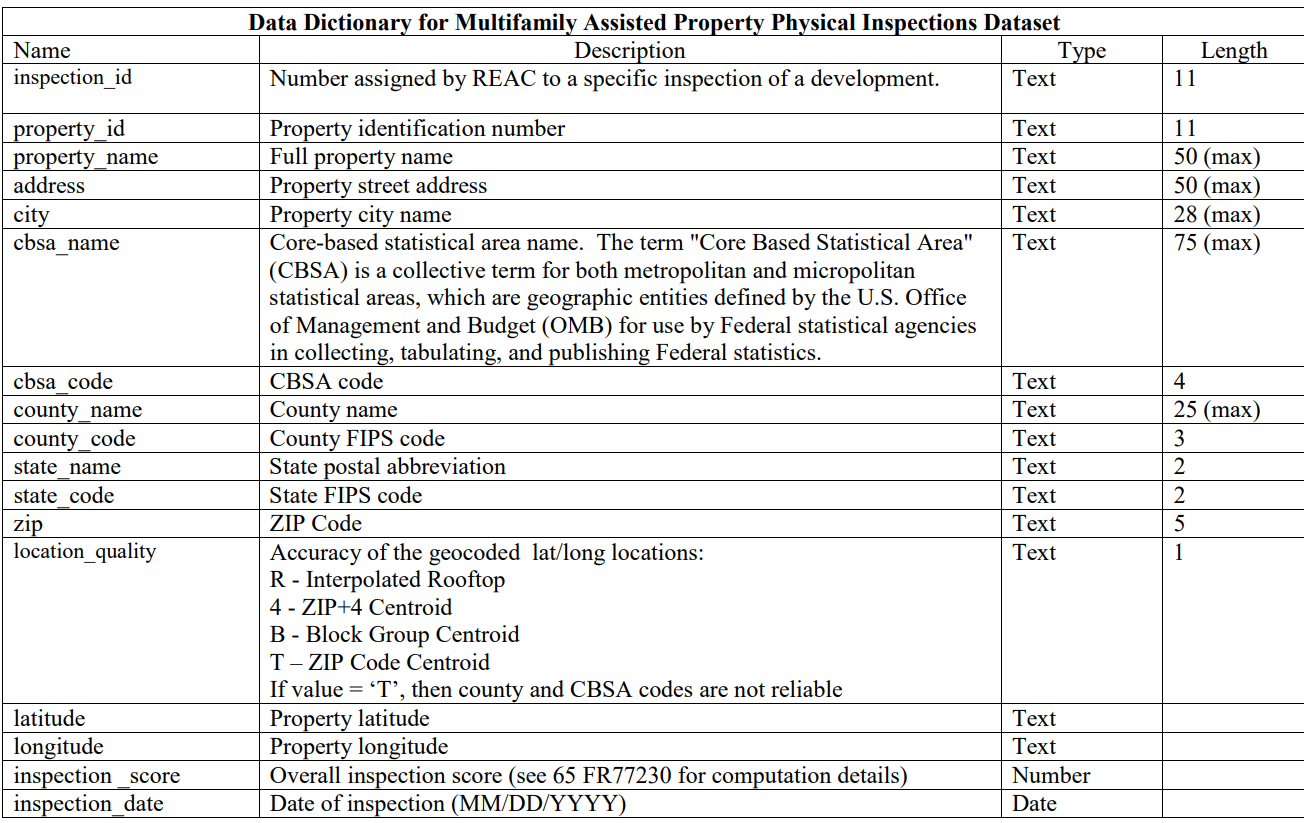

In [ ]:
inspect_df = pd.read_csv('https://raw.githubusercontent.com/ex-pr/projects/refs/heads/main/research_paper/data/HUD_data/multifamily-physical-inspection-scores-2016_Texas.csv')
inspect_df.head()

,INSPECTION_ID,PROPERTY_ID,PROPERTY_NAME,ADDRESS,CITY,CBSA_NAME,CBSA_CODE,COUNTY_NAME,COUNTY_CODE,STATE_NAME,STATE_CODE,ZIP,LATITUDE,LONGITUDE,LOCATION_QUALITY,INSPECTION_SCORE,INSPECTION_DATE
0,500202,800020943,HOUSTON HEIGHTS TOWERS,330 W 19th St,Houston,"Houston-The Woodlands-Sugar Land, TX Metropoli...",26420,Harris,201,TX,48,77008,29.802731,-95.402271,R,90,3/11/2013
1,500215,800219268,ALEMEDA VILLAS,2950 Alemeda St,Fort Worth,"Fort Worth-Arlington, TX Metropolitan Division",23104,Tarrant,439,TX,48,76108,32.732178,-97.485090,R,98,4/9/2013
2,500216,800216487,VISTAS of PINNACLE PARK,4599 W Davis St,Dallas,"Dallas-Plano-Irving, TX Metropolitan Division",19124,Dallas,113,TX,48,75211,32.749934,-96.897882,R,99,4/22/2013
3,500220,800021399,SUNSET HILLS APARTMENTS,900 Sunset Hls,San Augustine,NaN,99999,San Augustine,405,TX,48,75972,31.539601,-94.121389,R,92,4/11/2013
4,500303,800226778,EAGLEBROOK,10855 Eagle Dr,Mont Belvieu,"Houston-The Woodlands-Sugar Land, TX Metropoli...",26420,Chambers,71,TX,48,77523,29.850617,-94.860692,R,98,1/22/2013


# Data prep

## Merge data, Select Variables, Create New Variables

Owners - v2, Renters - v2, and Valid Registrations - v1 are primary sources. The Owners and Renters datasets provide aggregated county-level aid and damage data, aligning with the geospatial focus, while Valid Registrations offers applicant-level granularity for socio-economic and damage details. RI-IHP and Large Disasters can supplement or validate but are less critical due to overlap.

In [128]:
# Select columns
columns_to_keep = ['county', 'validRegistrations', 'averageFemaInspectedDamage', 'totalInspected', 'totalDamage', 'totalApprovedIhpAmount', 'approvedForFemaAssistance', 'noFemaInspectedDamage', 'repairReplaceAmount', 'rentalAmount', 'otherNeedsAmount']
owners_df_cols = owners_df[columns_to_keep].copy()

# Aggregate by county
owners_df_cols = owners_df_cols.groupby('county', as_index=False).agg({
    'validRegistrations': 'sum',
    'totalInspected': 'sum',
    'approvedForFemaAssistance': 'sum',
    'totalApprovedIhpAmount': 'sum',
    'repairReplaceAmount': 'sum',
    'rentalAmount': 'sum',
    'otherNeedsAmount': 'sum'
}).rename(columns=lambda x: 'owners_' + x if x != 'county' else x)

owners_df_cols.head(), owners_df_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 8 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   county                            41 non-null     object 
 1   owners_validRegistrations         41 non-null     int64  
 2   owners_totalInspected             41 non-null     int64  
 3   owners_approvedForFemaAssistance  41 non-null     int64  
 4   owners_totalApprovedIhpAmount     41 non-null     float64
 5   owners_repairReplaceAmount        41 non-null     float64
 6   owners_rentalAmount               41 non-null     float64
 7   owners_otherNeedsAmount           41 non-null     float64
dtypes: float64(4), int64(3), object(1)
memory usage: 2.7+ KB


(              county  owners_validRegistrations  owners_totalInspected  \
 0   Aransas (County)                       9309                   5723   
 1    Austin (County)                        576                    437   
 2   Bastrop (County)                        591                    463   
 3       Bee (County)                       1595                   1049   
 4  Brazoria (County)                      23647                  15130   
 
    owners_approvedForFemaAssistance  owners_totalApprovedIhpAmount  \
 0                              4848                    24273083.86   
 1                               244                     1058902.70   
 2                               226                      684536.55   
 3                               417                      714598.62   
 4                             12516                    66078315.63   
 
    owners_repairReplaceAmount  owners_rentalAmount  owners_otherNeedsAmount  
 0                 16005144.15           

In [129]:
# Select columns
columns_to_keep = ['county', 'validRegistrations', 'totalInspected', 'totalApprovedIhpAmount', 'approvedForFemaAssistance', 'rentalAmount', 'otherNeedsAmount']
renters_df_cols = renters_df[columns_to_keep].copy()

# Aggregate by county
renters_df_cols = renters_df_cols.groupby('county', as_index=False).agg({
    'validRegistrations': 'sum',
    'totalInspected': 'sum',
    'approvedForFemaAssistance': 'sum',
    'totalApprovedIhpAmount': 'sum',
    'rentalAmount': 'sum',
    'otherNeedsAmount': 'sum'
}).rename(columns=lambda x: 'renters_' + x if x != 'county' else x)

renters_df_cols.head(), renters_df_cols.info()

# Combine owners, renters
# First merge Owners and Renters
df = pd.merge(owners_df_cols, renters_df_cols, on='county', how='outer')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 7 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   county                             41 non-null     object 
 1   renters_validRegistrations         41 non-null     int64  
 2   renters_totalInspected             41 non-null     int64  
 3   renters_approvedForFemaAssistance  41 non-null     int64  
 4   renters_totalApprovedIhpAmount     41 non-null     float64
 5   renters_rentalAmount               41 non-null     float64
 6   renters_otherNeedsAmount           41 non-null     float64
dtypes: float64(3), int64(3), object(1)
memory usage: 2.4+ KB


(              county  renters_validRegistrations  renters_totalInspected  \
 0   Aransas (County)                        3750                    3159   
 1    Austin (County)                         258                     158   
 2   Bastrop (County)                         174                     134   
 3       Bee (County)                         685                     383   
 4  Brazoria (County)                       16256                    9019   
 
    renters_approvedForFemaAssistance  renters_totalApprovedIhpAmount  \
 0                               2455                      6254726.10   
 1                                 77                       147171.19   
 2                                 58                       116869.96   
 3                                189                       142333.93   
 4                               6271                      9011070.05   
 
    renters_rentalAmount  renters_otherNeedsAmount  
 0            3034283.38                313

In [206]:
#Percent of FEMA Registrations approved for assistance
regint_df_cols = regint_df.copy()
regint_df_cols['pct_ihp_eligible'] = regint_df_cols['ihpEligible'] / regint_df_cols['totalValidRegistrations']
regint_df_cols['pct_ha_eligible'] = regint_df_cols['haEligible'] / regint_df_cols['totalValidRegistrations']
regint_df_cols['pct_ona_eligible'] = regint_df_cols['onaEligible'] / regint_df_cols['totalValidRegistrations']

regint_df_cols['ihpPerCapita'] = regint_df_cols['ihpAmount'] / regint_df_cols['totalValidRegistrations']
regint_df_cols['haPerCapita'] = regint_df_cols['haAmount'] / regint_df_cols['totalValidRegistrations']
regint_df_cols['onaPerCapita'] = regint_df_cols['onaAmount'] / regint_df_cols['totalValidRegistrations']

#Select columns
columns_to_keep = ['county','totalValidRegistrations', 'pct_ihp_eligible', 'pct_ha_eligible', 'pct_ona_eligible', 'ihpPerCapita', 'haPerCapita', 'onaPerCapita']
regint_df_cols = regint_df_cols[columns_to_keep]
#Aggregate by county
regint_df_cols = regint_df_cols.groupby('county', as_index=False).sum()
regint_df_cols.head(), regint_df_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   county                   41 non-null     object 
 1   totalValidRegistrations  41 non-null     int64  
 2   pct_ihp_eligible         41 non-null     float64
 3   pct_ha_eligible          41 non-null     float64
 4   pct_ona_eligible         41 non-null     float64
 5   ihpPerCapita             41 non-null     float64
 6   haPerCapita              41 non-null     float64
 7   onaPerCapita             41 non-null     float64
dtypes: float64(6), int64(1), object(1)
memory usage: 2.7+ KB


(              county  totalValidRegistrations  pct_ihp_eligible  \
 0   Aransas (County)                    13171         15.710114   
 1    Austin (County)                      837          8.792460   
 2   Bastrop (County)                      767          7.621480   
 3       Bee (County)                     2295          3.120672   
 4  Brazoria (County)                    40067         40.419345   
 
    pct_ha_eligible  pct_ona_eligible   ihpPerCapita    haPerCapita  \
 0         5.250813         14.179113   41218.029700   31597.088746   
 1         4.413477          4.940030   22448.303267   18521.980383   
 2         3.924478          6.126226   28660.012164   21069.066559   
 3         1.562423          2.465420    7433.160738    5720.331638   
 4        15.897248         34.192932  146602.511915  104186.942387   
 
    onaPerCapita  
 0   9620.940954  
 1   3926.322884  
 2   7590.945605  
 3   1712.829100  
 4  42415.569528  ,
 None)

In [354]:
# Select columns
#columns_to_keep = ['county', 'applicantAge', 'householdComposition', 'grossIncome', 'ownRent',
                   #'homeOwnersInsurance', 'floodInsurance', 'fipAmount', 'ihpEligible', 'ihpAmount',
                  # 'haEligible', 'haAmount', 'onaEligible', 'onaAmount', 'rpfvl', 'ppfvl', 'waterLevel',
                   #'rentalAssistanceAmount', 'repairAmount', 'replacementAmount', 'personalPropertyAmount']

def clean_valid_registrations(df):
    """
    Clean and prepare the Valid Registrations dataset.

    Parameters
    ----------
    df : pandas.DataFrame
        Raw Valid Registrations data

    Returns
    -------
    pandas.DataFrame
        Cleaned data
    """
    print(f"Starting with {len(df)} records in Valid Registrations dataset")

    # Select relevant columns
    selected_columns = [
        'county', 'applicantAge', 'householdComposition', 'grossIncome', 'ownRent', 'homeOwnersInsurance', 'floodInsurance', 'fipAmount',
        'ihpEligible', 'ihpAmount', 'haEligible', 'haAmount', 'onaEligible', 'onaAmount', 'rpfvl', 'ppfvl', 'waterLevel',
        'floodDamageAmount', 'foundationDamageAmount', 'roofDamageAmount', 'rentalAssistanceAmount', 'repairAmount', 'replacementAmount',
        'personalPropertyAmount']

    #Keep only columns that exist in the data
    existing_columns = [col for col in selected_columns if col in df.columns]
    df = df[existing_columns].copy()

    #Convert boolean columns to integers (1/0)
    bool_columns = ['homeOwnersInsurance', 'floodInsurance', 'ihpEligible', 'haEligible', 'onaEligible']
    for col in bool_columns:
        if col in df.columns:
            df[col] = df[col].astype(int)

    #Create age groups as numeric
    if 'applicantAge' in df.columns:
        age_mapping = {
            '<19': 0,
            '19-34': 1,
            '35-49': 2,
            '50-64': 3,
            '65+': 4
        }
        df['age_numeric'] = df['applicantAge'].map(age_mapping).fillna(-1).astype(int)

    #Convert income categories to numeric values (midpoint of range)
    if 'grossIncome' in df.columns and df['grossIncome'].dtype == 'object':
        # Extract income ranges and convert to numeric
        income_mapping = {
            '<$15,000': 7500,
            '$15,000-$30,000': 22500,
            '$30,001-$60,000': 45000,
            '$60,001-$120,000': 90000,
            '>$120,000': 150000
        }
        df['income_numeric'] = df['grossIncome'].map(income_mapping).fillna(-1)

    #Convert ownership status to binary
    if 'ownRent' in df.columns:
        df['is_owner'] = (df['ownRent'] == 'Owner').astype(int)

    #Calculate total damage amount
    damage_columns = ['floodDamageAmount', 'foundationDamageAmount', 'roofDamageAmount']
    damage_cols_present = [col for col in damage_columns if col in df.columns]

    if damage_cols_present:
        df['total_damage'] = df[damage_cols_present].sum(axis=1)

    #Calculate total assistance amount
    assistance_columns = ['rentalAssistanceAmount', 'repairAmount', 'replacementAmount', 'personalPropertyAmount']
    assistance_cols_present = [col for col in assistance_columns if col in df.columns]

    if assistance_cols_present:
        df['total_assistance'] = df[assistance_cols_present].sum(axis=1)

    #Create insurance coverage indicator
    if 'homeOwnersInsurance' in df.columns and 'floodInsurance' in df.columns:
        df['has_any_insurance'] = ((df['homeOwnersInsurance'] == 1) | (df['floodInsurance'] == 1)).astype(int)

    # Log-transform monetary values to handle skewness
    money_columns = ['ihpAmount', 'haAmount', 'onaAmount', 'total_damage',
                     'total_assistance', 'repairAmount', 'personalPropertyAmount']

    for col in money_columns:
        if col in df.columns:
            df[f'{col}_log'] = np.log1p(df[col])

    #Calculate aid-to-damage ratio
    if 'total_assistance' in df.columns and 'total_damage' in df.columns:
        # Avoid division by zero
        mask = df['total_damage'] > 0
        df['aid_to_damage_ratio'] = np.nan
        df.loc[mask, 'aid_to_damage_ratio'] = df.loc[mask, 'total_assistance'] / df.loc[mask, 'total_damage']
        df['aid_to_damage_ratio'] = df['aid_to_damage_ratio'].clip(0, 10)  # Cap at 10x for outliers

    print(f"Cleaned Valid Registrations dataset contains {len(df)} records")
    return df

registrations_df_cols = registrations_df.copy()

registrations_df_cols = clean_valid_registrations(registrations_df_cols)

registrations_df_cols.head(10), registrations_df_cols.info()

Starting with 890924 records in Valid Registrations dataset
Cleaned Valid Registrations dataset contains 890924 records
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 890924 entries, 0 to 890923
Data columns (total 38 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   county                      890924 non-null  object 
 1   applicantAge                890924 non-null  object 
 2   householdComposition        890924 non-null  object 
 3   grossIncome                 890924 non-null  object 
 4   ownRent                     890924 non-null  object 
 5   homeOwnersInsurance         890924 non-null  int64  
 6   floodInsurance              890924 non-null  int64  
 7   fipAmount                   890924 non-null  int64  
 8   ihpEligible                 890924 non-null  int64  
 9   ihpAmount                   890924 non-null  float64
 10  haEligible                  890924 non-null  int64  
 11  haAmount  

(               county applicantAge householdComposition       grossIncome  \
 0     Harris (County)        50-64                    2  $60,001-$120,000   
 1     Harris (County)          65+                    2          <$15,000   
 2     Harris (County)        35-49                    2   $30,001-$60,000   
 3     Harris (County)        35-49                    4  $60,001-$120,000   
 4    Liberty (County)          65+                    1   $30,001-$60,000   
 5     Orange (County)        35-49                    3  $60,001-$120,000   
 6  Fort Bend (County)        35-49                    5   $30,001-$60,000   
 7     Harris (County)        35-49                    5  $60,001-$120,000   
 8     Harris (County)        35-49                   >5   $30,001-$60,000   
 9  Jefferson (County)        19-34                    1   $30,001-$60,000   
 
   ownRent  homeOwnersInsurance  floodInsurance  fipAmount  ihpEligible  \
 0   Owner                    1               0          0       

In [384]:
# Select columns
#columns_to_keep = ['censusBlockId', 'damagedZipCode', 'householdComposition', 'grossIncome', 'ownRent', 'homeOwnersInsurance', 'floodInsurance',
#                   'rpfvl', 'ppfvl', 'waterLevel', 'foundationDamageAmount', 'roofDamageAmount', 'rentalAssistanceAmount', 'repairAmount', 'personalPropertyAmount', 'residenceType']


def clean_large_disasters(df):
    """
    Clean and prepare the Large Disasters dataset.

    Parameters
    ----------
    df : pandas.DataFrame
        Raw Large Disasters data

    Returns
    -------
    pandas.DataFrame
        Cleaned data
    """
    print(f"Starting with {len(df)} records in Large Disasters dataset")

    # Select relevant columns
    selected_columns = [
        'damagedZipCode', 'censusBlockId', 'householdComposition',
        'grossIncome', 'specialNeeds', 'ownRent', 'residenceType',
        'homeOwnersInsurance', 'floodInsurance', 'rpfvl', 'ppfvl',
        'waterLevel', 'foundationDamageAmount', 'roofDamageAmount',
        'rentalAssistanceAmount', 'repairAmount', 'personalPropertyAmount']

    # Keep only columns that exist in the data
    existing_columns = [col for col in selected_columns if col in df.columns]
    df = df[existing_columns].copy()

    #Convert boolean columns to integers
    bool_columns = ['homeOwnersInsurance', 'floodInsurance']
    for col in bool_columns:
        if col in df.columns:
            df[col] = df[col].astype(int)

    #Create county information from censusBlockId
    if 'censusBlockId' in df.columns:
        #Extract county FIPS code from censusBlockId (positions 3-5)
        df['county_fips'] = df['censusBlockId'].astype(str).str[2:5]

        # #Load county FIPS to name mapping
        # #For now, we'll create a placeholder
        # try:
        #     fips_to_county = pd.read_csv('data_cache/county_fips_mapping.csv')
        #     fips_county_dict = dict(zip(fips_to_county['county_fips'], fips_to_county['county_name']))
        #     df['county'] = df['county_fips'].map(fips_county_dict)
        # except:
        #     print("County FIPS mapping file not found. County names will not be added.")

    #Convert ownership status to binary
    if 'ownRent' in df.columns:
        df['is_owner'] = (df['ownRent'] == 'Owner').astype(int)

    #Calculate total damage
    damage_columns = ['rpfvl', 'ppfvl']
    damage_cols_present = [col for col in damage_columns if col in df.columns]

    if damage_cols_present:
        # Fill NaN with 0 for damage calculation
        df['total_damage'] = df[damage_cols_present].fillna(0).sum(axis=1)

    #Calculate total assistance
    assistance_columns = ['rentalAssistanceAmount', 'repairAmount']
    assistance_cols_present = [col for col in assistance_columns if col in df.columns]

    if assistance_cols_present:
        df['total_assistance'] = df[assistance_cols_present].fillna(0).sum(axis=1)

    # Create residence type categories - FIXED INDENTATION HERE
    if 'residenceType' in df.columns:
        residence_mapping = {
            'Apartment': 'MultiUnit',
            'Assisted Living Facility': 'MultiUnit',
            'Boat': 'Other',
            'College Dorm': 'MultiUnit',
            'Condo': 'MultiUnit',
            'Correctional Facility': 'Other',
            'House/Duplex': 'SingleFamily',
            'Military Housing': 'Other',
            'Mobile Home': 'MobileHome',
            'Other': 'Other',
            'Townhouse': 'MultiUnit',
            'Travel Trailer': 'MobileHome',
            'Unknown': 'Other'
        }
        df['residence_category'] = df['residenceType'].map(residence_mapping)

        # One-hot encode residence categories
        if 'residence_category' in df.columns:
            residence_dummies = pd.get_dummies(df['residence_category'], prefix='residence')
            df = pd.concat([df, residence_dummies], axis=1)

    #Handle missing values in numeric fields
    numeric_cols = ['grossIncome', 'householdComposition', 'waterLevel']
    for col in numeric_cols:
        if col in df.columns:
            # Ensure column is numeric
            df[col] = pd.to_numeric(df[col], errors='coerce')
            # Replace negative values with NaN
            df[col] = df[col].mask(df[col] < 0, np.nan)

            # Replace NaN with median for each column
            df[col] = df[col].fillna(df[col].median())

    #Log-transform monetary values
    money_columns = ['grossIncome', 'rpfvl', 'ppfvl', 'total_damage', 'total_assistance']
    for col in money_columns:
        if col in df.columns and df[col].notnull().any():
            # Add 1 before log to handle zeros
            df[f'{col}_log'] = np.log1p(df[col])

    print(f"Cleaned Large Disasters dataset contains {len(df)} records")
    return df


large_disasters_df_cols = large_disasters_df.copy()
large_disasters_df_cols = clean_large_disasters(large_disasters_df_cols)

large_disasters_df_cols['county_fips'] = large_disasters_df_cols['censusBlockId'].astype(str).str[2:5]
fips_to_county = {
    '007': 'Aransas (County)',
    '015': 'Austin (County)',
    '021': 'Bastrop (County)',
    '025': 'Bee (County)',
    '039': 'Brazoria (County)',
    '045': 'Caldwell (County)',
    '057': 'Calhoun (County)',
    '071': 'Chambers (County)',
    '089': 'Colorado (County)',
    '123': 'DeWit (County)',
    '149': 'Fayette (County)',
    '157': 'Fort Bend (County)',
    '167': 'Galveston (County)',
    '175': 'Goliad (County)',
    '177': 'Gonzales (County)',
    '185': 'Grimes (County)',
    '199': 'Hardin (County)',
    '201': 'Harris (County)',
    '239': 'Jackson (County)',
    '241': 'Jasper (County)',
    '245': 'Jefferson (County)',
    '255': 'Karnes (County)',
    '273': 'Kleberg (County)',
    '285': 'Lavaca (County)',
    '287': 'Lee (County)',
    '291': 'Liberty (County)',
    '321': 'Matagorda (County)',
    '339': 'Montgomery (County)',
    '351': 'Newton (County)',
    '355': 'Nueces (County)',
    '361': 'Orange (County)',
    '373': 'Polk (County)',
    '391': 'Refugio (County)',
    '403': 'Sabine (County)',
    '407': 'San Jacinto (County)',
    '409': 'San Patricio (County)',
    '457': 'Tyler (County)',
    '469': 'Victoria (County)',
    '471': 'Walker (County)',
    '473': 'Waller (County)',
    '481': 'Wharton (County)'
}

large_disasters_df_cols['county_name'] = large_disasters_df_cols['county_fips'].map(fips_to_county)
large_disasters_df_cols.info(), large_disasters_df_cols.head()

Starting with 895619 records in Large Disasters dataset
Cleaned Large Disasters dataset contains 895619 records
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 895619 entries, 0 to 895618
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   damagedZipCode          895619 non-null  object 
 1   censusBlockId           894751 non-null  object 
 2   householdComposition    895619 non-null  int64  
 3   grossIncome             895619 non-null  float64
 4   specialNeeds            895619 non-null  bool   
 5   ownRent                 895619 non-null  object 
 6   residenceType           895619 non-null  object 
 7   homeOwnersInsurance     895619 non-null  int64  
 8   floodInsurance          895619 non-null  int64  
 9   rpfvl                   213458 non-null  float64
 10  ppfvl                   584141 non-null  float64
 11  waterLevel              895619 non-null  float64
 12  foundationDamage

(  damagedZipCode    censusBlockId  householdComposition  grossIncome  \
 0          77036  482014329011042                     1       1800.0   
 1          77088  482015327003002                     1      23000.0   
 2          77407  481576729001053                     1      80000.0   
 3          77701  482450019001038                     1      20400.0   
 4          77584  480396606022047                     3       5500.0   
 5          78418  483550031012015                     1      40000.0   
 6          77093  482012218002008                     5      12000.0   
 7          77951  484690017004028                     2      60000.0   
 8          77591  481677227001007                     2       2200.0   
 9          77396  482012502002000                     1      35000.0   
 
    specialNeeds ownRent   residenceType  homeOwnersInsurance  floodInsurance  \
 0          True  Renter       Apartment                    0               0   
 1         False  Renter       Ap

In [176]:
# Select columns
columns_to_keep = ['NAME', 'totalPopRace', 'medianIncome', 'pctMinority', 'povertyRate', 'homeOwnershipRate']
census_df_cols = census_data[columns_to_keep].copy()

# Choose counties as in FEMA data
census_df_cols['county'] = census_df_cols['NAME'].str.replace(' County, Texas', ' (County)')
census_df_cols = census_df_cols[census_df_cols['county'].isin(owners_df_cols['county'])]
census_df_cols = census_df_cols.drop(columns=['NAME'])

census_df_cols.head(), census_df_cols.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41 entries, 0 to 252
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   totalPopRace       41 non-null     int64  
 1   medianIncome       41 non-null     int64  
 2   pctMinority        41 non-null     float64
 3   povertyRate        41 non-null     float64
 4   homeOwnershipRate  41 non-null     float64
 5   county             41 non-null     object 
dtypes: float64(3), int64(2), object(1)
memory usage: 2.2+ KB


(    totalPopRace  medianIncome  pctMinority  povertyRate  homeOwnershipRate  \
 0          46974         43267     0.157215     0.187421           0.766958   
 3          31540         41700     0.124889     0.237494           0.530024   
 12         35444         41960     0.219614     0.168089           0.751378   
 13        254574         46315     0.414661     0.193962           0.618815   
 21         16850         55741     0.198398     0.137625           0.774600   
 
                 county  
 0        Polk (County)  
 3     Kleberg (County)  
 12     Jasper (County)  
 13  Jefferson (County)  
 21        Lee (County)  ,
 None)

In [208]:
#Choose counties as in FEMA data
storm_df_cols = storm_details.copy()
storm_df_cols['county'] = storm_df_cols['CZ_NAME'].str.title() + ' (County)'
storm_df_cols['county'] = storm_df_cols['county'].str.title().str.replace('De Witt (County)', 'DeWitt (County)')
storm_df_cols = storm_df_cols[storm_df_cols['county'].isin(owners_df_cols['county'])]
storm_df_cols = storm_df_cols.drop(columns=['CZ_NAME'])
storm_df_cols = storm_df_cols[storm_df_cols['BEGIN_DAY'] != 21]

#Convert damage strings (e.g., '10.0K', '1.5M') to numeric
def convert_damage_to_numeric(damage):
    if pd.isna(damage) or damage == '':
        return 0.0
    if isinstance(damage, str):
        damage = damage.upper().replace('$', '')  #Remove dollar signs if present
        if 'K' in damage:
            return float(damage.replace('K', '')) * 1000
        elif 'M' in damage:
            return float(damage.replace('M', '')) * 1000000
        elif 'B' in damage:
            return float(damage.replace('B', '')) * 1000000000
        else:
            return float(damage)
    return float(damage)

storm_df_cols['property_damage_numeric'] = storm_df_cols['DAMAGE_PROPERTY'].apply(convert_damage_to_numeric)
storm_df_cols['crop_damage_numeric'] = storm_df_cols['DAMAGE_CROPS'].apply(convert_damage_to_numeric)
storm_df_cols['sum_damage_noaa'] = storm_df_cols['property_damage_numeric'] + storm_df_cols['crop_damage_numeric']

#Group by county and sum damages
storm_df_cols = storm_df_cols.groupby(['county'])[['sum_damage_noaa']].sum().reset_index()

storm_df_cols.head(), storm_df_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   county           41 non-null     object 
 1   sum_damage_noaa  41 non-null     float64
dtypes: float64(1), object(1)
memory usage: 788.0+ bytes


(              county  sum_damage_noaa
 0   Aransas (County)     1.950000e+09
 1    Austin (County)     1.500000e+05
 2   Bastrop (County)     1.500000e+06
 3       Bee (County)     1.000000e+04
 4  Brazoria (County)     2.000880e+09,
 None)

In [236]:
nri_df_cols = nri_df.copy()
#Choose counties as in FEMA data
nri_df_cols['county'] = nri_df_cols['COUNTY'].str.title() + ' (County)'
nri_df_cols['county'] = nri_df_cols['county'].str.title().str.replace('Dewitt (County)', 'DeWitt (County)')
nri_df_cols = nri_df_cols[nri_df_cols['county'].isin(owners_df_cols['county'])]
nri_df_cols = nri_df_cols.dropna(subset=['RISK_VALUE'])

columns_to_keep = ['RISK_SCORE', 'SOVI_SCORE', 'RESL_SCORE', 'CRF_VALUE', 'county']
nri_df_cols = nri_df_cols[columns_to_keep]

nri_df_cols.info(), nri_df_cols.head()

<class 'pandas.core.frame.DataFrame'>
Index: 41 entries, 3 to 240
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   RISK_SCORE  41 non-null     float64
 1   SOVI_SCORE  41 non-null     float64
 2   RESL_SCORE  41 non-null     float64
 3   CRF_VALUE   41 non-null     object 
 4   county      41 non-null     object 
dtypes: float64(3), object(2)
memory usage: 1.9+ KB


(None,
     RISK_SCORE  SOVI_SCORE  RESL_SCORE    CRF_VALUE             county
 3    84.505250   93.760002   46.340000  1.181438352   Aransas (County)
 7    63.601654   76.129997   43.599998  1.399178234    Austin (County)
 10   78.587337   80.080002   35.959999  1.255466187   Bastrop (County)
 12   80.305441   94.720001   11.010000  1.518420627       Bee (County)
 19   99.109131   61.740002   71.709999  1.175315613  Brazoria (County))

In [ ]:
#Housing problem rates
chas_problems_df_cols = chas_problems_df.copy()
chas_problems_df_cols['owner_housing_problem_rate'] = chas_problems_df_cols['T11_est3'] / chas_problems_df_cols['T11_est2']
chas_problems_df_cols['renter_housing_problem_rate'] = chas_problems_df_cols['T11_est46'] / chas_problems_df_cols['T11_est45']

#Select columns
columns_to_keep = ['name', 'owner_housing_problem_rate', 'renter_housing_problem_rate']
chas_problems_df_cols = chas_problems_df_cols[columns_to_keep]

#Choose counties as in FEMA data
chas_problems_df_cols['county'] = chas_problems_df_cols['name'].str.replace(' County, Texas', ' (County)')
chas_problems_df_cols = chas_problems_df_cols[chas_problems_df_cols['county'].isin(owners_df_cols['county'])]
chas_problems_df_cols = chas_problems_df_cols.drop(columns=['name'])

chas_problems_df_cols.head(), chas_problems_df_cols.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41 entries, 3 to 240
Data columns (total 3 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   owner_housing_problem_rate   41 non-null     float64
 1   renter_housing_problem_rate  41 non-null     float64
 2   county                       41 non-null     object 
dtypes: float64(2), object(1)
memory usage: 1.3+ KB


(    owner_housing_problem_rate  renter_housing_problem_rate             county
 3                     0.233665                     0.485944   Aransas (County)
 7                     0.193272                     0.493849    Austin (County)
 10                    0.257659                     0.427518   Bastrop (County)
 12                    0.219535                     0.450079       Bee (County)
 19                    0.189693                     0.399452  Brazoria (County),
 None)

In [ ]:
#Race housing problem rates
chas_race_df_cols = chas_race_df.copy()
chas_race_df_cols['minority_owner_pct'] = (chas_race_df_cols['T9_est2'] - chas_race_df_cols['T9_est3'])/ chas_race_df_cols['T9_est2']
chas_race_df_cols['minority_renter_pct'] = (chas_race_df_cols['T9_est38'] - chas_race_df_cols['T9_est39'])/ chas_race_df_cols['T9_est38']

#Select columns
columns_to_keep = ['name', 'minority_owner_pct', 'minority_renter_pct']
chas_race_df_cols = chas_race_df_cols[columns_to_keep]

#Choose counties as in FEMA data
chas_race_df_cols['county'] = chas_race_df_cols['name'].str.replace(' County, Texas', ' (County)')
chas_race_df_cols = chas_race_df_cols[chas_race_df_cols['county'].isin(owners_df_cols['county'])]
chas_race_df_cols = chas_race_df_cols.drop(columns=['name'])

chas_race_df_cols.head(), chas_race_df_cols.info()

# Owner race percentages
# chas_race_df_cols['owner_pct_white'] = chas_race_df_cols['T9_est3'] / chas_race_df_cols['T9_est2']
# chas_race_df_cols['owner_pct_black'] = chas_race_df_cols['T9_est8'] / chas_race_df_cols['T9_est2']
# chas_race_df_cols['owner_pct_asian'] = chas_race_df_cols['T9_est13'] / chas_race_df_cols['T9_est2']
# chas_race_df_cols['owner_pct_hispanic'] = chas_race_df_cols['T9_est28'] / chas_race_df_cols['T9_est2']
# chas_race_df_cols['owner_pct_other'] = chas_race_df_cols['T9_est33'] / chas_race_df_cols['T9_est2']

# Renter race percentages
# chas_race_df_cols['renter_pct_white'] = chas_race_df_cols['T9_est39'] / chas_race_df_cols['T9_est38']
# chas_race_df_cols['renter_pct_black'] = chas_race_df_cols['T9_est44'] / chas_race_df_cols['T9_est38']
# chas_race_df_cols['renter_pct_asian'] = chas_race_df_cols['T9_est49'] / chas_race_df_cols['T9_est38']
# chas_race_df_cols['renter_pct_hispanic'] = chas_race_df_cols['T9_est64'] / chas_race_df_cols['T9_est38']
# chas_race_df_cols['renter_pct_other'] = chas_race_df_cols['T9_est69'] / chas_race_df_cols['T9_est38']

<class 'pandas.core.frame.DataFrame'>
Index: 41 entries, 3 to 240
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   minority_owner_pct   41 non-null     float64
 1   minority_renter_pct  41 non-null     float64
 2   county               41 non-null     object 
dtypes: float64(2), object(1)
memory usage: 1.3+ KB


(    minority_owner_pct  minority_renter_pct             county
 3             0.200284             0.393574   Aransas (County)
 7             0.236697             0.414763    Austin (County)
 10            0.318433             0.411138   Bastrop (County)
 12            0.546977             0.581616       Bee (County)
 19            0.400997             0.527076  Brazoria (County),
 None)

In [ ]:
#Housing age in 2017
acs_df_cols = acs_df.copy()
acs_df_cols['housing_age_renter'] = 2017 - acs_df_cols['B25037EST3']

#Select columns
columns_to_keep = ['NAME', 'B25002EST2_PCT', 'B25009EST2_PCT', 'B25009EST10_PCT', 'housing_age_renter']
acs_df_cols = acs_df_cols[columns_to_keep]
#Choose counties as in FEMA data
acs_df_cols['county'] = acs_df_cols['NAME'] + ' (County)'
acs_df_cols = acs_df_cols[acs_df_cols['county'].isin(owners_df_cols['county'])]
acs_df_cols = acs_df_cols.drop(columns=['NAME'])

#Change from percent to range 0-1
percent_columns = ['B25002EST2_PCT', 'B25009EST2_PCT', 'B25009EST10_PCT']
acs_df_cols[percent_columns] = acs_df_cols[percent_columns] / 100

acs_df_cols.head(), acs_df_cols.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41 entries, 5 to 234
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   B25002EST2_PCT      41 non-null     float64
 1   B25009EST2_PCT      41 non-null     float64
 2   B25009EST10_PCT     41 non-null     float64
 3   housing_age_renter  41 non-null     int64  
 4   county              41 non-null     object 
dtypes: float64(3), int64(1), object(1)
memory usage: 1.9+ KB


(    B25002EST2_PCT  B25009EST2_PCT  B25009EST10_PCT  housing_age_renter  \
 5           0.7309          0.7045           0.2955                  38   
 6           0.7899          0.7611           0.2389                  35   
 8           0.8629          0.6154           0.3846                  38   
 12          0.7513          0.8042           0.1958                  39   
 13          0.8250          0.7006           0.2994                  36   
 
                 county  
 5     Jackson (County)  
 6      Jasper (County)  
 8   Jefferson (County)  
 12     Goliad (County)  
 13   Gonzales (County)  ,
 None)

In [169]:
#Select columns
columns_to_keep = ['COUNTY_NAME', 'INSPECTION_SCORE']
inspect_df_cols = inspect_df[columns_to_keep].copy()

#No 'Goliad, Lee, Newton,  Sabine, San Jacinto, Tyler due to their rural nature, small populations, and limited HUD-assisted multifamily properties,
#with possible additional factors like inspection timing and data availability

#Choose counties as in FEMA data
inspect_df_cols['county'] = inspect_df_cols['COUNTY_NAME'] + ' (County)'
inspect_df_cols['county'] = inspect_df_cols['county'].str.title().str.replace('Dewitt (County)', 'DeWitt (County)')
inspect_df_cols = inspect_df_cols[inspect_df_cols['county'].isin(owners_df_cols['county'])]
inspect_df_cols = inspect_df_cols.drop(columns=['COUNTY_NAME'])
inspect_df_cols = inspect_df_cols.groupby('county', as_index=False)['INSPECTION_SCORE'].mean()

#Missing counties
missing_counties = ['Goliad (County)', 'Lee (County)', 'Newton (County)', 'Sabine (County)', 'San Jacinto (County)', 'Tyler (County)']
missing_df = pd.DataFrame({'county': missing_counties, 'INSPECTION_SCORE': [np.nan] * len(missing_counties)})

inspect_df_cols = pd.concat([inspect_df_cols, missing_df], ignore_index=True)

inspect_df_cols.head(), inspect_df_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   county            41 non-null     object 
 1   INSPECTION_SCORE  35 non-null     float64
dtypes: float64(1), object(1)
memory usage: 788.0+ bytes


(              county  INSPECTION_SCORE
 0   Aransas (County)         99.000000
 1    Austin (County)         93.500000
 2   Bastrop (County)         87.714286
 3       Bee (County)         80.000000
 4  Brazoria (County)         88.153846,
 None)

In [310]:
#Merge county datasets
county_df = regint_df_cols.merge(census_df_cols, on='county', how='outer')\
                         .merge(storm_df_cols, on='county', how='outer')\
                         .merge(nri_df_cols[['county', 'CRF_VALUE']], on='county', how='outer')\
                         #.merge(chas_problems_df_cols, on='county', how='outer')\
                         #.merge(chas_race_df_cols, on='county', how='outer')\
                         #.merge(acs_df_cols, on='county', how='outer')\
                         #.merge(inspect_df_cols, on='county', how='outer')
county_df['CRF_VALUE'] = pd.to_numeric(county_df['CRF_VALUE'], errors='coerce')

county_df.head(), county_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   county                   41 non-null     object 
 1   totalValidRegistrations  41 non-null     int64  
 2   pct_ihp_eligible         41 non-null     float64
 3   pct_ha_eligible          41 non-null     float64
 4   pct_ona_eligible         41 non-null     float64
 5   ihpPerCapita             41 non-null     float64
 6   haPerCapita              41 non-null     float64
 7   onaPerCapita             41 non-null     float64
 8   totalPopRace             41 non-null     int64  
 9   medianIncome             41 non-null     int64  
 10  pctMinority              41 non-null     float64
 11  povertyRate              41 non-null     float64
 12  homeOwnershipRate        41 non-null     float64
 13  sum_damage_noaa          41 non-null     float64
 14  CRF_VALUE                41 

(              county  totalValidRegistrations  pct_ihp_eligible  \
 0   Aransas (County)                    13171         15.710114   
 1    Austin (County)                      837          8.792460   
 2   Bastrop (County)                      767          7.621480   
 3       Bee (County)                     2295          3.120672   
 4  Brazoria (County)                    40067         40.419345   
 
    pct_ha_eligible  pct_ona_eligible   ihpPerCapita    haPerCapita  \
 0         5.250813         14.179113   41218.029700   31597.088746   
 1         4.413477          4.940030   22448.303267   18521.980383   
 2         3.924478          6.126226   28660.012164   21069.066559   
 3         1.562423          2.465420    7433.160738    5720.331638   
 4        15.897248         34.192932  146602.511915  104186.942387   
 
    onaPerCapita  totalPopRace  medianIncome  pctMinority  povertyRate  \
 0   9620.940954         24832         44601     0.122101     0.178413   
 1   3926.3228

## Housing resiliance score

In [311]:
#Combine datasets
hud_score_df = chas_problems_df_cols \
    .merge(chas_race_df_cols, on='county') \
    .merge(acs_df_cols, on='county') \
    .merge(inspect_df_cols, on='county', how='left')

#List of variables to normalize
vars_to_normalize = [
    'owner_housing_problem_rate', 'renter_housing_problem_rate',
    'minority_owner_pct', 'minority_renter_pct',
    'housing_age_renter', 'INSPECTION_SCORE'
]

#Original (non-normalized) versions for later
for col in vars_to_normalize:
    hud_score_df[f'{col}_raw'] = hud_score_df[col]

#Normalize only selected variables
scaler = MinMaxScaler()
hud_score_df[vars_to_normalize] = scaler.fit_transform(hud_score_df[vars_to_normalize])

#Housing Resilience Score
hud_score_df['HRS'] = (
    0.2 * (1 - hud_score_df['owner_housing_problem_rate']) +
    0.2 * (1 - hud_score_df['renter_housing_problem_rate']) +
    0.1 * (1 - hud_score_df['minority_owner_pct']) +
    0.1 * (1 - hud_score_df['minority_renter_pct']) +
    0.2 * (1 - hud_score_df['housing_age_renter']) +
    0.2 * hud_score_df['INSPECTION_SCORE']
)

hud_score_df.head(), hud_score_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   owner_housing_problem_rate       41 non-null     float64
 1   renter_housing_problem_rate      41 non-null     float64
 2   county                           41 non-null     object 
 3   minority_owner_pct               41 non-null     float64
 4   minority_renter_pct              41 non-null     float64
 5   B25002EST2_PCT                   41 non-null     float64
 6   B25009EST2_PCT                   41 non-null     float64
 7   B25009EST10_PCT                  41 non-null     float64
 8   housing_age_renter               41 non-null     float64
 9   INSPECTION_SCORE                 35 non-null     float64
 10  owner_housing_problem_rate_raw   41 non-null     float64
 11  renter_housing_problem_rate_raw  41 non-null     float64
 12  minority_owner_pct_raw  

(   owner_housing_problem_rate  renter_housing_problem_rate             county  \
 0                    0.827139                     0.840597   Aransas (County)   
 1                    0.559893                     0.860834    Austin (County)   
 2                    0.985892                     0.691033   Bastrop (County)   
 3                    0.733653                     0.748787       Bee (County)   
 4                    0.536213                     0.619186  Brazoria (County)   
 
    minority_owner_pct  minority_renter_pct  B25002EST2_PCT  B25009EST2_PCT  \
 0            0.189374             0.385098          0.6103          0.8185   
 1            0.249945             0.418020          0.8676          0.7844   
 2            0.385906             0.412388          0.8600          0.7854   
 3            0.766071             0.677274          0.7926          0.6475   
 4            0.523246             0.592530          0.8905          0.7330   
 
    B25009EST10_PCT  housing_a

In [312]:
from sklearn.decomposition import PCA

# Use only variables involved in the score
X = hud_score_df[vars_to_normalize].copy().dropna()

# Fit PCA
pca = PCA(n_components=1)
pca.fit(X)

# Get the absolute value of loadings (direction doesn't matter for weights)
pca_weights = abs(pca.components_[0])
pca_weights = pca_weights / pca_weights.sum()  # Normalize to sum to 1

# Combine into a score
hud_score_df['HRS_PCA'] = X.dot(pca_weights)

# Optional: Normalize the final score
hud_score_df['HRS_PCA'] = (hud_score_df['HRS_PCA'] - hud_score_df['HRS_PCA'].min()) / (hud_score_df['HRS_PCA'].max() - hud_score_df['HRS_PCA'].min())

# Show weights
dict(zip(vars_to_normalize, pca_weights))


{'owner_housing_problem_rate': np.float64(0.08038382566383372),
 'renter_housing_problem_rate': np.float64(0.05117461907431243),
 'minority_owner_pct': np.float64(0.29355070981621184),
 'minority_renter_pct': np.float64(0.29034169174622837),
 'housing_age_renter': np.float64(0.11120871910528721),
 'INSPECTION_SCORE': np.float64(0.17334043459412637)}

In [313]:
from sklearn.linear_model import LinearRegression

# Merge with target
hud_score_clean = hud_score_df.copy().dropna(subset=vars_to_normalize)
X = hud_score_clean[vars_to_normalize].copy()
y = county_df.set_index('county').loc[hud_score_clean['county'], 'ihpPerCapita'].values

# Fit regression
reg = LinearRegression()
reg.fit(X, y)

# Use absolute value of coefficients as weights (normalized)
reg_weights = abs(reg.coef_)
reg_weights = reg_weights / reg_weights.sum()

# Combine into score
hud_score_clean['HRS_REG'] = X.dot(reg_weights)
hud_score_clean['HRS_REG'] = (hud_score_clean['HRS_REG'] - hud_score_clean['HRS_REG'].min()) / (hud_score_clean['HRS_REG'].max() - hud_score_clean['HRS_REG'].min())
hud_score_clean['HRS_EQ'] = X.mean(axis=1)

# Invert if lower values mean worse conditions
hud_score_clean['HRS_EQ'] = 1 - hud_score_clean['HRS_EQ']

# Show weights
dict(zip(vars_to_normalize, reg_weights))

{'owner_housing_problem_rate': np.float64(0.07687056753867252),
 'renter_housing_problem_rate': np.float64(0.11044960317908176),
 'minority_owner_pct': np.float64(0.0963350222764192),
 'minority_renter_pct': np.float64(0.11067328028218432),
 'housing_age_renter': np.float64(0.6008317289465506),
 'INSPECTION_SCORE': np.float64(0.004839797777091716)}

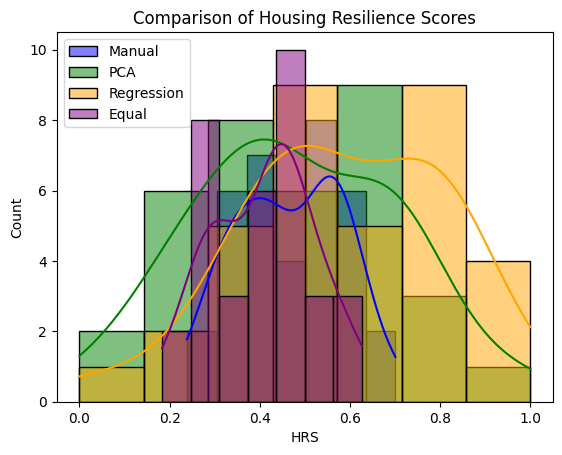

In [314]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(hud_score_clean['HRS'], kde=True, label='Manual', color='blue')
sns.histplot(hud_score_clean['HRS_PCA'], kde=True, label='PCA', color='green')
sns.histplot(hud_score_clean['HRS_REG'], kde=True, label='Regression', color='orange')
sns.histplot(hud_score_clean['HRS_EQ'], kde=True, label='Equal', color='purple')
plt.legend()
plt.title("Comparison of Housing Resilience Scores")
plt.show()

## NRI component

In [315]:
nri_vars = nri_df_cols[['county', 'RISK_SCORE', 'SOVI_SCORE', 'RESL_SCORE']].copy()

#Normalize and invert RISK + SOVI
scaler = MinMaxScaler()
nri_vars[['RISK_SCORE_NORM', 'SOVI_SCORE_NORM']] = 1 - scaler.fit_transform(nri_vars[['RISK_SCORE', 'SOVI_SCORE']])
nri_vars[['RESL_SCORE_NORM']] = scaler.fit_transform(nri_vars[['RESL_SCORE']])

#NRI score manual
nri_vars['NRIS'] = (
    0.3 * nri_vars['RISK_SCORE_NORM'] +
    0.3 * nri_vars['SOVI_SCORE_NORM'] +
    0.4 * nri_vars['RESL_SCORE_NORM']
)

nri_vars.head(), nri_vars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41 entries, 3 to 240
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   county           41 non-null     object 
 1   RISK_SCORE       41 non-null     float64
 2   SOVI_SCORE       41 non-null     float64
 3   RESL_SCORE       41 non-null     float64
 4   RISK_SCORE_NORM  41 non-null     float64
 5   SOVI_SCORE_NORM  41 non-null     float64
 6   RESL_SCORE_NORM  41 non-null     float64
 7   NRIS             41 non-null     float64
dtypes: float64(7), object(1)
memory usage: 2.9+ KB


(               county  RISK_SCORE  SOVI_SCORE  RESL_SCORE  RISK_SCORE_NORM  \
 3    Aransas (County)   84.505250   93.760002   46.340000         0.211580   
 7     Austin (County)   63.601654   76.129997   43.599998         0.497606   
 10   Bastrop (County)   78.587337   80.080002   35.959999         0.292556   
 12       Bee (County)   80.305441   94.720001   11.010000         0.269047   
 19  Brazoria (County)   99.109131   61.740002   71.709999         0.011754   
 
     SOVI_SCORE_NORM  RESL_SCORE_NORM      NRIS  
 3          0.093231         0.483439  0.284819  
 7          0.421965         0.452359  0.456815  
 10         0.348313         0.365699  0.338540  
 12         0.075331         0.082691  0.136389  
 19         0.690285         0.771211  0.519097  ,
 None)

In [316]:
nri_features = ['RISK_SCORE', 'SOVI_SCORE', 'RESL_SCORE']

#Normalize
scaler = MinMaxScaler()
X_nri = scaler.fit_transform(nri_vars[nri_features])
X_nri = 1 - X_nri  # Invert since high RISK and SOVI are bad, like you did before

#Fit PCA
pca = PCA(n_components=1)
pca.fit(X_nri)

#Extract weights
pca_weights = abs(pca.components_[0])
pca_weights = pca_weights / pca_weights.sum()

#Score
nri_vars['NRIS_PCA'] = X_nri.dot(pca_weights)
nri_vars['NRIS_PCA'] = (nri_vars['NRIS_PCA'] - nri_vars['NRIS_PCA'].min()) / (nri_vars['NRIS_PCA'].max() - nri_vars['NRIS_PCA'].min())

#Weights
dict(zip(nri_features, pca_weights))

{'RISK_SCORE': np.float64(0.01699173366471679),
 'SOVI_SCORE': np.float64(0.6288064398162209),
 'RESL_SCORE': np.float64(0.35420182651906235)}

In [317]:
#Align
aligned = nri_vars.set_index('county').join(county_df.set_index('county')[['ihpPerCapita']], how='inner')
X = scaler.fit_transform(aligned[['RISK_SCORE', 'SOVI_SCORE', 'RESL_SCORE']])
X = 1 - X  #Invert for RISK and SOVI

#Fit regression
reg = LinearRegression()
reg.fit(X, aligned['ihpPerCapita'])

#Get weights
reg_weights = abs(reg.coef_)
reg_weights = reg_weights / reg_weights.sum()

#Apply to NRI vars
nri_vars['NRIS_REG'] = X.dot(reg_weights)
nri_vars['NRIS_REG'] = (nri_vars['NRIS_REG'] - nri_vars['NRIS_REG'].min()) / (nri_vars['NRIS_REG'].max() - nri_vars['NRIS_REG'].min())

dict(zip(['RISK_SCORE', 'SOVI_SCORE', 'RESL_SCORE'], reg_weights))

{'RISK_SCORE': np.float64(0.5458597973375029),
 'SOVI_SCORE': np.float64(0.20397991164486182),
 'RESL_SCORE': np.float64(0.2501602910176354)}

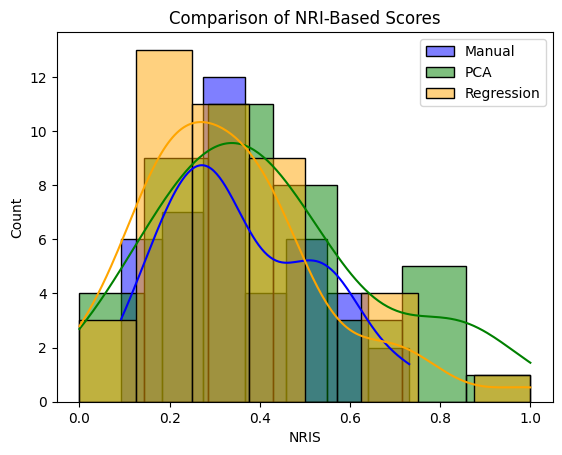

In [318]:
sns.histplot(nri_vars['NRIS'], kde=True, label='Manual', color='blue')
sns.histplot(nri_vars['NRIS_PCA'], kde=True, label='PCA', color='green')
sns.histplot(nri_vars['NRIS_REG'], kde=True, label='Regression', color='orange')
plt.legend()
plt.title("Comparison of NRI-Based Scores")
plt.show()

In [319]:
# Merge county_df with hud_hrs  and NRIS
hud_hrs = hud_score_df[['county', 'HRS_PCA']].copy()
county_df = county_df.merge(hud_hrs, on='county', how='outer')

nris = nri_vars[['county', 'NRIS_PCA']].copy()
county_df = county_df.merge(nris, on='county', how='outer')

county_df.head(), county_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   county                   41 non-null     object 
 1   totalValidRegistrations  41 non-null     int64  
 2   pct_ihp_eligible         41 non-null     float64
 3   pct_ha_eligible          41 non-null     float64
 4   pct_ona_eligible         41 non-null     float64
 5   ihpPerCapita             41 non-null     float64
 6   haPerCapita              41 non-null     float64
 7   onaPerCapita             41 non-null     float64
 8   totalPopRace             41 non-null     int64  
 9   medianIncome             41 non-null     int64  
 10  pctMinority              41 non-null     float64
 11  povertyRate              41 non-null     float64
 12  homeOwnershipRate        41 non-null     float64
 13  sum_damage_noaa          41 non-null     float64
 14  CRF_VALUE                41 

(              county  totalValidRegistrations  pct_ihp_eligible  \
 0   Aransas (County)                    13171         15.710114   
 1    Austin (County)                      837          8.792460   
 2   Bastrop (County)                      767          7.621480   
 3       Bee (County)                     2295          3.120672   
 4  Brazoria (County)                    40067         40.419345   
 
    pct_ha_eligible  pct_ona_eligible   ihpPerCapita    haPerCapita  \
 0         5.250813         14.179113   41218.029700   31597.088746   
 1         4.413477          4.940030   22448.303267   18521.980383   
 2         3.924478          6.126226   28660.012164   21069.066559   
 3         1.562423          2.465420    7433.160738    5720.331638   
 4        15.897248         34.192932  146602.511915  104186.942387   
 
    onaPerCapita  totalPopRace  medianIncome  pctMinority  povertyRate  \
 0   9620.940954         24832         44601     0.122101     0.178413   
 1   3926.3228

## Data Transformation

In [322]:
#Log-transform highly skewed variables
for col in ['sum_damage_noaa', 'ihpPerCapita', 'haPerCapita', 'onaPerCapita']:
    county_df[f'{col}_log'] = np.log1p(county_df[col])  # log(1+x) to handle zeros

#Standardize variables for modeling
from sklearn.preprocessing import StandardScaler

#Variables to standardize
std_cols = ['medianIncome', 'pctMinority', 'povertyRate', 'homeOwnershipRate']
scaler = StandardScaler()
county_df[std_cols] = scaler.fit_transform(county_df[std_cols])

county_df.describe(), county_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   county                   41 non-null     object 
 1   totalValidRegistrations  41 non-null     int64  
 2   pct_ihp_eligible         41 non-null     float64
 3   pct_ha_eligible          41 non-null     float64
 4   pct_ona_eligible         41 non-null     float64
 5   ihpPerCapita             41 non-null     float64
 6   haPerCapita              41 non-null     float64
 7   onaPerCapita             41 non-null     float64
 8   totalPopRace             41 non-null     int64  
 9   medianIncome             41 non-null     float64
 10  pctMinority              41 non-null     float64
 11  povertyRate              41 non-null     float64
 12  homeOwnershipRate        41 non-null     float64
 13  sum_damage_noaa          41 non-null     float64
 14  CRF_VALUE                41 

(       totalValidRegistrations  pct_ihp_eligible  pct_ha_eligible  \
 count                41.000000         41.000000        41.000000   
 mean              21729.853659         16.365008         6.709054   
 std               70565.332725         25.689332         8.428791   
 min                 213.000000          0.659522         0.192467   
 25%                1029.000000          4.121155         2.364594   
 50%                2362.000000          8.092396         3.924478   
 75%               13171.000000         17.858800         9.260064   
 max              449336.000000        157.663146        50.941659   
 
        pct_ona_eligible   ihpPerCapita    haPerCapita   onaPerCapita  \
 count         41.000000      41.000000      41.000000      41.000000   
 mean          13.447612   58504.318536   42133.917957   16370.400580   
 std           22.597385   85751.094237   60416.502383   25982.433628   
 min            0.537149     793.330614     485.381838     307.948776   
 25

## Imputation

# EDA

### Distribution plots of key variables:

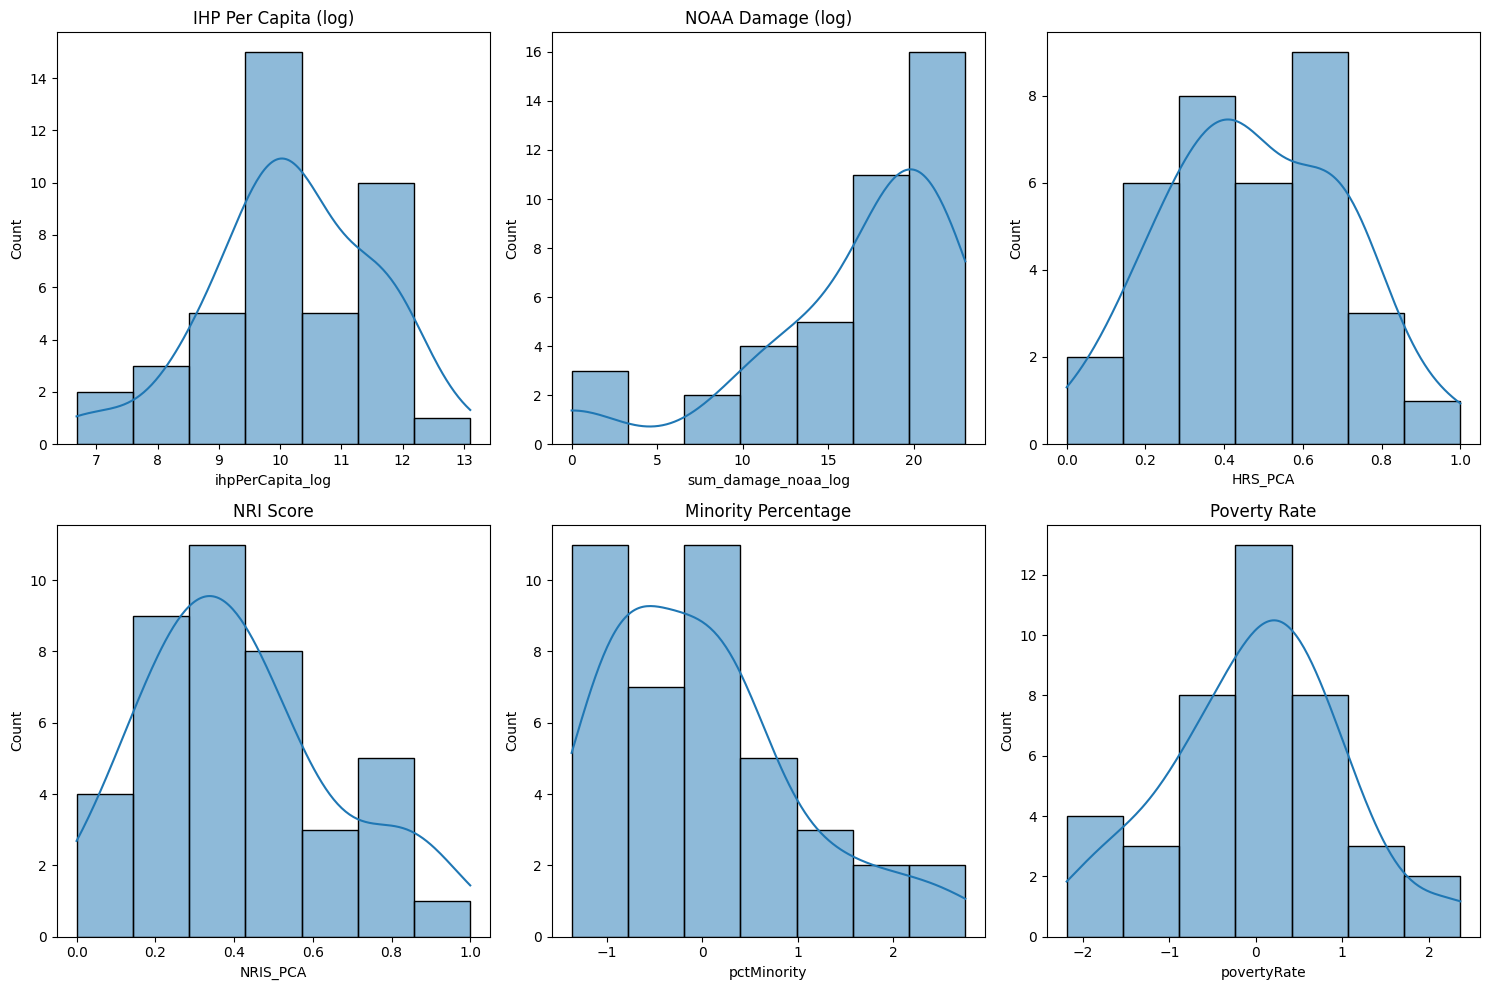

In [338]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

#Plot distributions of key variables
sns.histplot(county_df['ihpPerCapita_log'], kde=True, ax=axes[0])
axes[0].set_title('IHP Per Capita (log)')

sns.histplot(county_df['sum_damage_noaa_log'], kde=True, ax=axes[1])
axes[1].set_title('NOAA Damage (log)')

sns.histplot(county_df['HRS_PCA'], kde=True, ax=axes[2])
axes[3].set_title('Housing Vulnerability Score')

sns.histplot(county_df['NRIS_PCA'], kde=True, ax=axes[3])
axes[3].set_title('NRI Score')

sns.histplot(county_df['pctMinority'], kde=True, ax=axes[4])
axes[4].set_title('Minority Percentage')

sns.histplot(county_df['povertyRate'], kde=True, ax=axes[5])
axes[5].set_title('Poverty Rate')

plt.tight_layout()
plt.show()

In [364]:
def explore_valid_registrations(df):
    """
    Perform exploratory data analysis on Valid Registrations dataset.

    Parameters
    ----------
    df : pandas.DataFrame
        Cleaned Valid Registrations data

    Returns
    -------
    None
    """
    print("\n" + "="*50)
    print("EXPLORATORY ANALYSIS - VALID REGISTRATIONS DATASET")
    print("="*50)

    #Basic statistics
    print("\n--- Basic Statistics ---")
    print(f"Number of records: {len(df)}")
    print(f"Number of counties: {df['county'].nunique()}")

    #Aid distribution statistics
    money_cols = ['ihpAmount', 'haAmount', 'onaAmount', 'repairAmount',
                  'replacementAmount', 'personalPropertyAmount']

    print("\n--- Aid Distribution Statistics ---")
    for col in money_cols:
        if col in df.columns:
            non_zero = df[df[col] > 0]
            print(f"{col}:")
            print(f"  Mean: ${non_zero[col].mean():.2f}")
            print(f"  Median: ${non_zero[col].median():.2f}")
            print(f"  Max: ${non_zero[col].max():.2f}")
            print(f"  Records receiving aid: {len(non_zero)} ({len(non_zero)/len(df)*100:.1f}%)")

    #Eligibility rates
    eligibility_cols = ['ihpEligible', 'haEligible', 'onaEligible']
    print("\n--- Eligibility Rates ---")
    for col in eligibility_cols:
        if col in df.columns:
            print(f"{col}: {df[col].mean()*100:.1f}%")

    #Insurance coverage
    insurance_cols = ['homeOwnersInsurance', 'floodInsurance']
    print("\n--- Insurance Coverage ---")
    for col in insurance_cols:
        if col in df.columns:
            print(f"{col}: {df[col].mean()*100:.1f}%")

    #Age distribution
    if 'applicantAge' in df.columns:
        print("\n--- Age Distribution ---")
        age_dist = df['applicantAge'].value_counts(normalize=True) * 100
        for age, pct in age_dist.items():
            print(f"{age}: {pct:.1f}%")

    #Homeownership rates
    if 'ownRent' in df.columns:
        print("\n--- Homeownership ---")
        ownership = df['ownRent'].value_counts(normalize=True) * 100
        for status, pct in ownership.items():
            print(f"{status}: {pct:.1f}%")

    #Income distribution
    if 'grossIncome' in df.columns:
        print("\n--- Income Distribution ---")
        income_dist = df['grossIncome'].value_counts(normalize=True) * 100
        for income, pct in income_dist.items():
            print(f"{income}: {pct:.1f}%")

    #Aid by demographics
    print("\n--- Aid Distribution by Demographics ---")

    #Aid by homeownership
    if 'ownRent' in df.columns and 'ihpAmount' in df.columns:
        aid_by_ownership = df.groupby('ownRent')['ihpAmount'].agg(['mean', 'median', 'count'])
        print("\nAid by Ownership Status:")
        print(aid_by_ownership)

    #Aid by age group
    if 'applicantAge' in df.columns and 'ihpAmount' in df.columns:
        aid_by_age = df.groupby('applicantAge')['ihpAmount'].agg(['mean', 'median', 'count'])
        print("\nAid by Age Group:")
        print(aid_by_age)

    #Aid by income
    if 'grossIncome' in df.columns and 'ihpAmount' in df.columns:
        aid_by_income = df.groupby('grossIncome')['ihpAmount'].agg(['mean', 'median', 'count'])
        print("\nAid by Income Group:")
        print(aid_by_income)

    #Aid by insurance status
    if 'homeOwnersInsurance' in df.columns and 'ihpAmount' in df.columns:
        aid_by_insurance = df.groupby('homeOwnersInsurance')['ihpAmount'].agg(['mean', 'median', 'count'])
        print("\nAid by Home Insurance Status:")
        print(aid_by_insurance)

    #Aid by county (top 10)
    if 'county' in df.columns and 'ihpAmount' in df.columns:
        aid_by_county = df.groupby('county').agg({
            'ihpAmount': ['mean', 'median', 'sum', 'count']
        }).sort_values(('ihpAmount', 'sum'), ascending=False)

        print("\nAid by County (Top 10):")
        print(aid_by_county.head(10))

     #Correlation analysis
    print("\n--- Correlation Analysis ---")

    #Select numeric columns for correlation
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

    #Filter out ID columns and columns with all zeros
    exclude_patterns = ['id', '_id', 'number', 'fips']
    exclude_cols = [col for col in numeric_cols if any(pattern in col.lower() for pattern in exclude_patterns)]

    #Also exclude columns with very low variance
    for col in numeric_cols:
        if col not in exclude_cols and df[col].nunique() < 3:
            exclude_cols.append(col)

    correlation_cols = [col for col in numeric_cols if col not in exclude_cols]

    if len(correlation_cols) > 1:
        #Calculate correlations with aid amounts
        aid_cols = [col for col in ['ihpAmount', 'haAmount', 'onaAmount'] if col in correlation_cols]

        if aid_cols:
            predictors = [col for col in correlation_cols if col not in aid_cols]
            correlations = []

            for aid_col in aid_cols:
                for predictor in predictors:
                    corr = df[[aid_col, predictor]].corr().iloc[0, 1]
                    correlations.append((aid_col, predictor, corr))

            #Convert to DataFrame and sort
            corr_df = pd.DataFrame(correlations, columns=['Aid', 'Predictor', 'Correlation'])
            corr_df = corr_df.sort_values('Correlation', ascending=False)

            print("Top correlations with aid amounts:")
            print(corr_df.head(10))

    return

explore_valid_registrations(registrations_df_cols)


EXPLORATORY ANALYSIS - VALID REGISTRATIONS DATASET

--- Basic Statistics ---
Number of records: 890924
Number of counties: 41

--- Aid Distribution Statistics ---
ihpAmount:
  Mean: $4441.19
  Median: $897.01
  Max: $61244.69
  Records receiving aid: 373083 (41.9%)
haAmount:
  Mean: $7210.93
  Median: $2822.78
  Max: $57802.00
  Records receiving aid: 172417 (19.4%)
onaAmount:
  Mean: $1339.06
  Median: $500.00
  Max: $33300.00
  Records receiving aid: 308907 (34.7%)
repairAmount:
  Mean: $10231.32
  Median: $9110.94
  Max: $38780.82
  Records receiving aid: 87476 (9.8%)
replacementAmount:
  Mean: $24161.52
  Median: $29370.70
  Max: $33300.00
  Records receiving aid: 438 (0.0%)
personalPropertyAmount:
  Mean: $2905.59
  Median: $2012.00
  Max: $21397.19
  Records receiving aid: 82039 (9.2%)

--- Eligibility Rates ---
ihpEligible: 41.9%
haEligible: 19.4%
onaEligible: 34.7%

--- Insurance Coverage ---
homeOwnersInsurance: 31.8%
floodInsurance: 11.4%

--- Age Distribution ---
35-49: 31.

In [390]:
def explore_large_disasters(df):
    """
    Perform exploratory data analysis on the Large Disasters dataset.

    Parameters
    ----------
    df : pandas.DataFrame
        Cleaned Large Disasters dataset

    Returns
    -------
    None
        Prints analysis results and generates visualizations
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    from matplotlib.gridspec import GridSpec

    # Set visualization style
    plt.style.use('ggplot')
    sns.set_palette('deep')

    print("\n" + "="*50)
    print("EXPLORATORY ANALYSIS - LARGE DISASTERS DATASET")
    print("="*50)

    #Basic dataset overview
    print("\n--- DATASET OVERVIEW ---")
    total_records = len(df)
    print(f"Total records: {total_records:,}")
    total_counties = df['county_name'].nunique() if 'county_name' in df.columns else df['county_fips'].nunique()
    print(f"Total counties: {total_counties}")

    #Missing data assessment
    print("\n--- MISSING DATA ASSESSMENT ---")
    key_cols = [
        'censusBlockId', 'householdComposition', 'grossIncome', 'specialNeeds',
        'ownRent', 'residenceType', 'homeOwnersInsurance', 'floodInsurance',
        'rpfvl', 'ppfvl', 'waterLevel', 'foundationDamageAmount', 'roofDamageAmount',
        'rentalAssistanceAmount', 'repairAmount'
    ]

    missing_data = []
    for col in key_cols:
        if col in df.columns:
            missing_count = df[col].isna().sum()
            missing_pct = missing_count / len(df) * 100
            missing_data.append({
                'Column': col,
                'Missing Count': f"{missing_count:,}",
                'Missing %': f"{missing_pct:.1f}%",
                'Present %': f"{100-missing_pct:.1f}%"
            })

    # Print the missing data table
    print(pd.DataFrame(missing_data).to_string(index=False))

    #Demographic characteristics
    print("\n--- DEMOGRAPHIC CHARACTERISTICS ---")

    #Housing tenure
    if 'ownRent' in df.columns:
        tenure_counts = df['ownRent'].value_counts()
        total_valid = tenure_counts.sum()
        print("Housing Tenure:")
        for tenure, count in tenure_counts.items():
            print(f"  {tenure}: {count:,} ({count/total_valid*100:.1f}%)")

    #Household composition (size)
    if 'householdComposition' in df.columns:
        hh_stats = df['householdComposition'].describe()
        print(f"\nHousehold Size:")
        print(f"  Mean: {hh_stats['mean']:.2f}")
        print(f"  Median: {hh_stats['50%']:.1f}")
        print(f"  Max: {hh_stats['max']:.0f}")

        # Distribution table of household sizes
        hh_counts = df['householdComposition'].value_counts().sort_index()
        print("\nHousehold Size Distribution:")
        for size, count in hh_counts.items():
            if size <= 10:  # Show only up to household size of 10
                print(f"  {size} person(s): {count:,} ({count/len(df)*100:.1f}%)")

    #Income distribution
    if 'grossIncome' in df.columns:
        income_stats = df['grossIncome'].describe(percentiles=[0.25, 0.5, 0.75, 0.9])
        print(f"\nIncome Statistics:")
        print(f"  Mean: ${income_stats['mean']:.2f}")
        print(f"  Median: ${income_stats['50%']:.2f}")
        print(f"  90th percentile: ${income_stats['90%']:.2f}")

        # Create income brackets for better interpretation
        brackets = [0, 15000, 30000, 50000, 75000, 100000, float('inf')]
        labels = ['<$15K', '$15K-$30K', '$30K-$50K', '$50K-$75K', '$75K-$100K', '>$100K']
        df['income_bracket'] = pd.cut(df['grossIncome'], bins=brackets, labels=labels)

        income_dist = df['income_bracket'].value_counts().sort_index()
        print("\nIncome Bracket Distribution:")
        for bracket, count in income_dist.items():
            print(f"  {bracket}: {count:,} ({count/len(df)*100:.1f}%)")

    #Housing characteristics
    print("\n--- HOUSING CHARACTERISTICS ---")

    # Residence types
    if 'residenceType' in df.columns:
        residence_counts = df['residenceType'].value_counts()
        total_valid = residence_counts.sum()

        print("Residence Types:")
        for res_type, count in residence_counts.items():
            print(f"  {res_type}: {count:,} ({count/total_valid*100:.1f}%)")

        # Consolidated residence categories
        if 'residence_category' in df.columns:
            category_counts = df['residence_category'].value_counts()
            print("\nConsolidated Residence Categories:")
            for category, count in category_counts.items():
                print(f"  {category}: {count:,} ({count/total_valid*100:.1f}%)")

    #Insurance coverage
    if 'homeOwnersInsurance' in df.columns and 'floodInsurance' in df.columns:
        home_ins_pct = df['homeOwnersInsurance'].mean() * 100
        flood_ins_pct = df['floodInsurance'].mean() * 100

        print(f"\nInsurance Coverage:")
        print(f"  Home insurance: {df['homeOwnersInsurance'].sum():,} ({home_ins_pct:.1f}%)")
        print(f"  Flood insurance: {df['floodInsurance'].sum():,} ({flood_ins_pct:.1f}%)")

        # Combined insurance status
        both_ins = (df['homeOwnersInsurance'] & df['floodInsurance']).sum()
        both_ins_pct = both_ins / len(df) * 100

        home_only = (df['homeOwnersInsurance'] & ~df['floodInsurance']).sum()
        home_only_pct = home_only / len(df) * 100

        flood_only = (~df['homeOwnersInsurance'] & df['floodInsurance']).sum()
        flood_only_pct = flood_only / len(df) * 100

        no_ins = (~df['homeOwnersInsurance'] & ~df['floodInsurance']).sum()
        no_ins_pct = no_ins / len(df) * 100

        print("\nCombined Insurance Status:")
        print(f"  Both insurances: {both_ins:,} ({both_ins_pct:.1f}%)")
        print(f"  Home insurance only: {home_only:,} ({home_only_pct:.1f}%)")
        print(f"  Flood insurance only: {flood_only:,} ({flood_only_pct:.1f}%)")
        print(f"  No insurance: {no_ins:,} ({no_ins_pct:.1f}%)")

        # Insurance by ownership and residence type
        if 'is_owner' in df.columns:
            owner_ins = df[df['is_owner'] == 1]['homeOwnersInsurance'].mean() * 100
            renter_ins = df[df['is_owner'] == 0]['homeOwnersInsurance'].mean() * 100

            print("\nInsurance by Housing Tenure:")
            print(f"  Owners with home insurance: {owner_ins:.1f}%")
            print(f"  Renters with home insurance: {renter_ins:.1f}%")

    #Damage assessment
    print("\n--- DAMAGE ASSESSMENT ---")

    #Property damage (rpfvl and ppfvl)
    if 'rpfvl' in df.columns:
        rpfvl_present = df['rpfvl'].notnull().sum()
        rpfvl_present_pct = rpfvl_present / len(df) * 100
        rpfvl_nonzero = (df['rpfvl'] > 0).sum()
        rpfvl_nonzero_pct = rpfvl_nonzero / rpfvl_present * 100 if rpfvl_present > 0 else 0

        print(f"Real Property FEMA Verified Loss (RPFVL):")
        print(f"  Records with RPFVL data: {rpfvl_present:,} ({rpfvl_present_pct:.1f}% of all records)")

        if rpfvl_nonzero > 0:
            rpfvl_stats = df[df['rpfvl'] > 0]['rpfvl'].describe(percentiles=[0.25, 0.5, 0.75, 0.9])
            print(f"  Non-zero RPFVL records: {rpfvl_nonzero:,} ({rpfvl_nonzero_pct:.1f}% of records with RPFVL data)")
            print(f"  Mean RPFVL (non-zero): ${rpfvl_stats['mean']:.2f}")
            print(f"  Median RPFVL (non-zero): ${rpfvl_stats['50%']:.2f}")
            print(f"  90th percentile (non-zero): ${rpfvl_stats['90%']:.2f}")

    if 'ppfvl' in df.columns:
        ppfvl_present = df['ppfvl'].notnull().sum()
        ppfvl_present_pct = ppfvl_present / len(df) * 100
        ppfvl_nonzero = (df['ppfvl'] > 0).sum()
        ppfvl_nonzero_pct = ppfvl_nonzero / ppfvl_present * 100 if ppfvl_present > 0 else 0

        print(f"\nPersonal Property FEMA Verified Loss (PPFVL):")
        print(f"  Records with PPFVL data: {ppfvl_present:,} ({ppfvl_present_pct:.1f}% of all records)")

        if ppfvl_nonzero > 0:
            ppfvl_stats = df[df['ppfvl'] > 0]['ppfvl'].describe(percentiles=[0.25, 0.5, 0.75, 0.9])
            print(f"  Non-zero PPFVL records: {ppfvl_nonzero:,} ({ppfvl_nonzero_pct:.1f}% of records with PPFVL data)")
            print(f"  Mean PPFVL (non-zero): ${ppfvl_stats['mean']:.2f}")
            print(f"  Median PPFVL (non-zero): ${ppfvl_stats['50%']:.2f}")
            print(f"  90th percentile (non-zero): ${ppfvl_stats['90%']:.2f}")

    #Water level
    if 'waterLevel' in df.columns:
        water_nonzero = (df['waterLevel'] > 0).sum()
        water_nonzero_pct = water_nonzero / len(df) * 100

        print(f"\nWater Level:")
        print(f"  Records with water damage: {water_nonzero:,} ({water_nonzero_pct:.1f}% of all records)")

        if water_nonzero > 0:
            water_stats = df[df['waterLevel'] > 0]['waterLevel'].describe(percentiles=[0.25, 0.5, 0.75, 0.9])
            print(f"  Mean water level (non-zero): {water_stats['mean']:.1f} inches")
            print(f"  Median water level (non-zero): {water_stats['50%']:.1f} inches")
            print(f"  90th percentile (non-zero): {water_stats['90%']:.1f} inches")
            print(f"  Maximum water level: {water_stats['max']:.1f} inches")

    #Assistance received
    print("\n--- ASSISTANCE RECEIVED ---")

    #Rental assistance
    if 'rentalAssistanceAmount' in df.columns:
        rental_nonzero = (df['rentalAssistanceAmount'] > 0).sum()
        rental_nonzero_pct = rental_nonzero / len(df) * 100

        print(f"Rental Assistance:")
        print(f"  Recipients: {rental_nonzero:,} ({rental_nonzero_pct:.1f}% of all records)")

        if rental_nonzero > 0:
            rental_stats = df[df['rentalAssistanceAmount'] > 0]['rentalAssistanceAmount'].describe(
                percentiles=[0.25, 0.5, 0.75, 0.9]
            )
            print(f"  Mean rental assistance: ${rental_stats['mean']:.2f}")
            print(f"  Median rental assistance: ${rental_stats['50%']:.2f}")
            print(f"  90th percentile: ${rental_stats['90%']:.2f}")

    #Repair assistance
    if 'repairAmount' in df.columns:
        repair_nonzero = (df['repairAmount'] > 0).sum()
        repair_nonzero_pct = repair_nonzero / len(df) * 100

        print(f"\nRepair Assistance:")
        print(f"  Recipients: {repair_nonzero:,} ({repair_nonzero_pct:.1f}% of all records)")

        if repair_nonzero > 0:
            repair_stats = df[df['repairAmount'] > 0]['repairAmount'].describe(
                percentiles=[0.25, 0.5, 0.75, 0.9]
            )
            print(f"  Mean repair assistance: ${repair_stats['mean']:.2f}")
            print(f"  Median repair assistance: ${repair_stats['50%']:.2f}")
            print(f"  90th percentile: ${repair_stats['90%']:.2f}")

    #Total assistance
    if 'total_assistance' in df.columns:
        assist_nonzero = (df['total_assistance'] > 0).sum()
        assist_nonzero_pct = assist_nonzero / len(df) * 100

        print(f"\nTotal Assistance:")
        print(f"  Recipients: {assist_nonzero:,} ({assist_nonzero_pct:.1f}% of all records)")

        if assist_nonzero > 0:
            assist_stats = df[df['total_assistance'] > 0]['total_assistance'].describe(
                percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
            )
            print(f"  Mean total assistance: ${assist_stats['mean']:.2f}")
            print(f"  Median total assistance: ${assist_stats['50%']:.2f}")
            print(f"  90th percentile: ${assist_stats['90%']:.2f}")
            print(f"  99th percentile: ${assist_stats['99%']:.2f}")
            print(f"  Maximum assistance: ${assist_stats['max']:.2f}")


    #Aid vs. Damage analysis
    if 'total_damage' in df.columns and 'total_assistance' in df.columns:
        print("\n--- AID vs. DAMAGE ANALYSIS ---")

        # 7.1 Records with both damage and aid
        has_both = (df['total_damage'] > 0) & (df['total_assistance'] > 0)
        both_count = has_both.sum()
        both_pct_all = both_count / len(df) * 100

        print(f"Records with both damage & aid: {both_count:,} ({both_pct_all:.1f}% of all records)")

        #Records with damage but no aid
        damage_no_aid = (df['total_damage'] > 0) & (df['total_assistance'] == 0)
        damage_no_aid_count = damage_no_aid.sum()

        if damage_no_aid_count > 0:
            damage_no_aid_pct = damage_no_aid_count / (df['total_damage'] > 0).sum() * 100
            print(f"Records with damage but no aid: {damage_no_aid_count:,} ({damage_no_aid_pct:.1f}% of records with damage)")

        # 7.3 Records with aid but no reported damage
        aid_no_damage = (df['total_damage'] == 0) & (df['total_assistance'] > 0)
        aid_no_damage_count = aid_no_damage.sum()

        if aid_no_damage_count > 0:
            aid_no_damage_pct = aid_no_damage_count / (df['total_assistance'] > 0).sum() * 100
            print(f"Records with aid but no reported damage: {aid_no_damage_count:,} ({aid_no_damage_pct:.1f}% of records with aid)")

        #Aid-to-damage ratio for records with both
        if both_count > 0:
            both_df = df[has_both].copy()
            both_df['aid_damage_ratio'] = both_df['total_assistance'] / both_df['total_damage']

            #Clip extreme ratios for analysis
            both_df['aid_damage_ratio_clipped'] = both_df['aid_damage_ratio'].clip(0, 5)

            ratio_stats = both_df['aid_damage_ratio_clipped'].describe(
                percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]
            )

            print(f"\nAid-to-Damage Ratio Statistics (for records with both, capped at 5):")
            print(f"  Mean ratio: {ratio_stats['mean']:.2f}")
            print(f"  10th percentile: {ratio_stats['10%']:.2f}")
            print(f"  Median ratio: {ratio_stats['50%']:.2f}")
            print(f"  90th percentile: {ratio_stats['90%']:.2f}")

            # Ratio distribution
            ratio_bins = [0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 5.0]
            ratio_labels = ['<25%', '25-50%', '50-75%', '75-100%', '100-150%', '150-200%', '>200%']

            both_df['ratio_bracket'] = pd.cut(
                both_df['aid_damage_ratio_clipped'],
                bins=ratio_bins,
                labels=ratio_labels
            )

            ratio_dist = both_df['ratio_bracket'].value_counts().sort_index()
            total_with_ratio = ratio_dist.sum()

            print("\nAid as percentage of damage:")
            for bracket, count in ratio_dist.items():
                print(f"  {bracket}: {count:,} ({count/total_with_ratio*100:.1f}%)")

            # Fully compensated vs. undercompensated
            fully_comp = (both_df['aid_damage_ratio'] >= 1.0).sum()
            fully_comp_pct = fully_comp / both_count * 100

            print(f"\nFully Compensated (aid ≥ damage): {fully_comp:,} ({fully_comp_pct:.1f}% of records with both)")
            print(f"Undercompensated (aid < damage): {both_count - fully_comp:,} ({100 - fully_comp_pct:.1f}% of records with both)")

    #Geographic distribution
    if 'county_name' in df.columns:
        print("\n--- GEOGRAPHIC DISTRIBUTION ---")

        county_counts = df['county_name'].value_counts().head(10)
        total_records = len(df)

        print("Top 10 Counties by Number of Records:")
        for county, count in county_counts.items():
            print(f"  {county}: {count:,} ({count/total_records*100:.1f}%)")

        #Damage and aid by county
        if 'total_damage' in df.columns and 'total_assistance' in df.columns:
            #Aggregate damage and aid by county
            county_stats = df.groupby('county_name').agg({
                'total_damage': 'sum',
                'total_assistance': 'sum',
                'censusBlockId': 'count'
            }).rename(columns={'censusBlockId': 'record_count'})

            #Calculate per-record averages
            county_stats['avg_damage'] = county_stats['total_damage'] / county_stats['record_count']
            county_stats['avg_assistance'] = county_stats['total_assistance'] / county_stats['record_count']

            #Calculate aid-to-damage ratio at county level
            county_stats['aid_damage_ratio'] = county_stats['total_assistance'] / county_stats['total_damage']
            county_stats['aid_damage_ratio'] = county_stats['aid_damage_ratio'].fillna(0)

            #Sort by total damage
            top_counties_damage = county_stats.sort_values('total_damage', ascending=False).head(10)

            print("\nTop 10 Counties by Total Damage:")
            for county, row in top_counties_damage.iterrows():
                print(f"  {county}: ${row['total_damage']:,.2f} total, ${row['avg_damage']:,.2f} avg/record")

            #Sort by total assistance
            top_counties_assistance = county_stats.sort_values('total_assistance', ascending=False).head(10)

            print("\nTop 10 Counties by Total Assistance:")
            for county, row in top_counties_assistance.iterrows():
                print(f"  {county}: ${row['total_assistance']:,.2f} total, ${row['avg_assistance']:,.2f} avg/record")

            #Counties with highest and lowest aid-damage ratios
            valid_ratios = county_stats[county_stats['total_damage'] > 100000]  # Only counties with significant damage

            top_ratio_counties = valid_ratios.sort_values('aid_damage_ratio', ascending=False).head(5)
            print("\nTop 5 Counties by Aid-to-Damage Ratio (with significant damage):")
            for county, row in top_ratio_counties.iterrows():
                print(f"  {county}: {row['aid_damage_ratio']:.2f} ratio, ${row['total_damage']:,.2f} damage")

            bottom_ratio_counties = valid_ratios.sort_values('aid_damage_ratio').head(5)
            print("\nBottom 5 Counties by Aid-to-Damage Ratio (with significant damage):")
            for county, row in bottom_ratio_counties.iterrows():
                print(f"  {county}: {row['aid_damage_ratio']:.2f} ratio, ${row['total_damage']:,.2f} damage")


    #Analysis by ownership status
    if 'is_owner' in df.columns:
        # Calculate approval rates by ownership
        if 'total_assistance' in df.columns and 'total_damage' in df.columns:
            #Owners with damage who received aid
            owners_with_damage = df[(df['is_owner'] == 1) & (df['total_damage'] > 0)]
            owners_with_aid = owners_with_damage[owners_with_damage['total_assistance'] > 0]

            owner_approval_rate = len(owners_with_aid) / len(owners_with_damage) * 100 if len(owners_with_damage) > 0 else 0

            #Renters with damage who received aid
            renters_with_damage = df[(df['is_owner'] == 0) & (df['total_damage'] > 0)]
            renters_with_aid = renters_with_damage[renters_with_damage['total_assistance'] > 0]

            renter_approval_rate = len(renters_with_aid) / len(renters_with_damage) * 100 if len(renters_with_damage) > 0 else 0

            print("\nAid Approval Rates by Housing Tenure:")
            print(f"  Owners with damage: {len(owners_with_damage):,}")
            print(f"  Owners receiving aid: {len(owners_with_aid):,} ({owner_approval_rate:.1f}%)")
            print(f"  Renters with damage: {len(renters_with_damage):,}")
            print(f"  Renters receiving aid: {len(renters_with_aid):,} ({renter_approval_rate:.1f}%)")

#Average aid amounts
            if len(owners_with_aid) > 0 and len(renters_with_aid) > 0:
                owner_avg_aid = owners_with_aid['total_assistance'].mean()
                renter_avg_aid = renters_with_aid['total_assistance'].mean()

                print("\nAverage Aid Amounts for Recipients:")
                print(f"  Owners: ${owner_avg_aid:.2f}")
                print(f"  Renters: ${renter_avg_aid:.2f}")
                print(f"  Difference: ${owner_avg_aid - renter_avg_aid:.2f}")

                #Aid-to-damage ratios
                owners_with_both = owners_with_damage[owners_with_damage['total_assistance'] > 0]
                owners_with_both['aid_ratio'] = owners_with_both['total_assistance'] / owners_with_both['total_damage']

                renters_with_both = renters_with_damage[renters_with_damage['total_assistance'] > 0]
                renters_with_both['aid_ratio'] = renters_with_both['total_assistance'] / renters_with_both['total_damage']

                owner_median_ratio = owners_with_both['aid_ratio'].median()
                renter_median_ratio = renters_with_both['aid_ratio'].median()

                print("\nMedian Aid-to-Damage Ratios:")
                print(f"  Owners: {owner_median_ratio:.2f}")
                print(f"  Renters: {renter_median_ratio:.2f}")

    #Statistical Relationships
    print("\n--- STATISTICAL RELATIONSHIPS ---")

    #orrelations between key variables
    numeric_cols = [
        'grossIncome', 'householdComposition', 'waterLevel',
        'rpfvl', 'ppfvl', 'total_damage', 'total_assistance'
    ]

    # Keep only columns that exist in the dataframe
    available_cols = [col for col in numeric_cols if col in df.columns]

    #Calculate correlations for available variables
    if len(available_cols) >= 2:
        corr_matrix = df[available_cols].corr()

        # Print formatted correlation matrix (rounded to 2 decimals)
        print("Correlation Matrix:")
        print(pd.DataFrame(np.round(corr_matrix, 2),
                          index=corr_matrix.index,
                          columns=corr_matrix.columns).to_string())

        #Highlight key relationships
        if 'total_damage' in available_cols and 'total_assistance' in available_cols:
            damage_aid_corr = corr_matrix.loc['total_damage', 'total_assistance']
            print(f"\nCorrelation between damage and aid: {damage_aid_corr:.4f}")

        if 'grossIncome' in available_cols and 'total_assistance' in available_cols:
            income_aid_corr = corr_matrix.loc['grossIncome', 'total_assistance']
            print(f"Correlation between income and aid: {income_aid_corr:.4f}")

        if 'grossIncome' in available_cols and 'total_damage' in available_cols:
            income_damage_corr = corr_matrix.loc['grossIncome', 'total_damage']
            print(f"Correlation between income and damage: {income_damage_corr:.4f}")

    #Assistance by income bracket
    if all(col in df.columns for col in ['grossIncome', 'total_assistance', 'total_damage']):
        # Analyze aid approval and amounts by income bracket
        if 'income_bracket' in df.columns:
            # Calculate approval rates and aid amounts by income bracket
            income_analysis = df[df['total_damage'] > 0].groupby('income_bracket').agg({
                'censusBlockId': 'count',
                'total_assistance': lambda x: (x > 0).sum() / len(x) * 100,  # Approval rate
                'total_damage': 'mean',  # Average damage
                'total_assistance': lambda x: x[x > 0].mean() if len(x[x > 0]) > 0 else 0  # Average aid (if approved)
            }).rename(columns={
                'censusBlockId': 'applicants_with_damage',
                'total_assistance': 'avg_aid_if_approved',
                'total_damage': 'avg_damage'
            })

            # Create ratio of average aid to average damage
            income_analysis['aid_to_damage_ratio'] = income_analysis['avg_aid_if_approved'] / income_analysis['avg_damage']

            print("\nAssistance Analysis by Income Bracket:")
            print(income_analysis)

    return

explore_large_disasters(large_disasters_df_cols)


EXPLORATORY ANALYSIS - LARGE DISASTERS DATASET

--- DATASET OVERVIEW ---
Total records: 895,619
Total counties: 40

--- MISSING DATA ASSESSMENT ---
                Column Missing Count Missing % Present %
         censusBlockId           868      0.1%     99.9%
  householdComposition             0      0.0%    100.0%
           grossIncome             0      0.0%    100.0%
          specialNeeds             0      0.0%    100.0%
               ownRent             0      0.0%    100.0%
         residenceType             0      0.0%    100.0%
   homeOwnersInsurance             0      0.0%    100.0%
        floodInsurance             0      0.0%    100.0%
                 rpfvl       682,161     76.2%     23.8%
                 ppfvl       311,478     34.8%     65.2%
            waterLevel             0      0.0%    100.0%
foundationDamageAmount       882,885     98.6%      1.4%
      roofDamageAmount       850,109     94.9%      5.1%
rentalAssistanceAmount       752,047     84.0%     16

<ipython-input-390-65defdc2db09>:423: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  owners_with_both['aid_ratio'] = owners_with_both['total_assistance'] / owners_with_both['total_damage']
<ipython-input-390-65defdc2db09>:426: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  renters_with_both['aid_ratio'] = renters_with_both['total_assistance'] / renters_with_both['total_damage']



Median Aid-to-Damage Ratios:
  Owners: 0.83
  Renters: 0.59

--- STATISTICAL RELATIONSHIPS ---
Correlation Matrix:
                      grossIncome  householdComposition  waterLevel  rpfvl  ppfvl  total_damage  total_assistance
grossIncome                  1.00                  0.01        0.01   0.03   0.01          0.02              0.01
householdComposition         0.01                  1.00        0.10   0.00   0.19          0.13              0.13
waterLevel                   0.01                  0.10        1.00   0.65   0.61          0.65              0.45
rpfvl                        0.03                  0.00        0.65   1.00   0.63          0.99              0.54
ppfvl                        0.01                  0.19        0.61   0.63   1.00          0.69              0.59
total_damage                 0.02                  0.13        0.65   0.99   0.69          1.00              0.70
total_assistance             0.01                  0.13        0.45   0.54   0.59     

<ipython-input-390-65defdc2db09>:475: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_analysis = df[df['total_damage'] > 0].groupby('income_bracket').agg({


### Relationship plots between key predictors and outcomes:

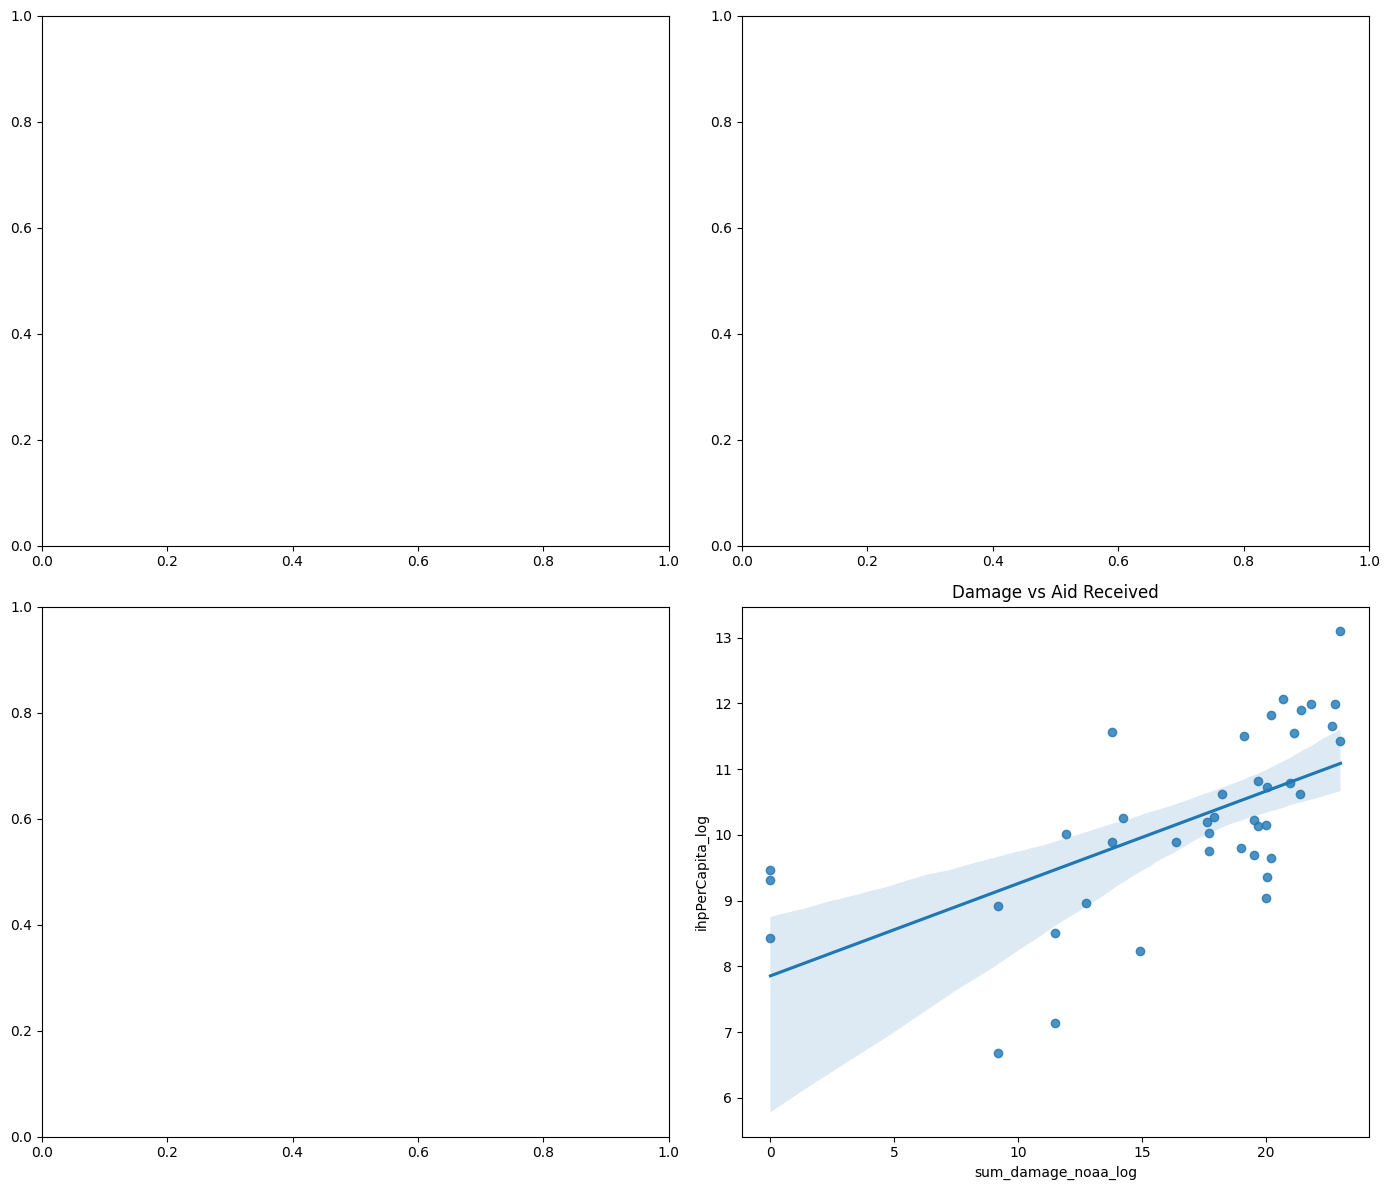

In [340]:
#Scatter plots with regression lines
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

#Relationship between damage and aid
sns.regplot(x='sum_damage_noaa_log', y='ihpPerCapita_log', data=county_df, ax=axes[3])
axes[3].set_title('Damage vs Aid Received')

plt.tight_layout()
plt.show()

### Correlation heatmap to identify relationships

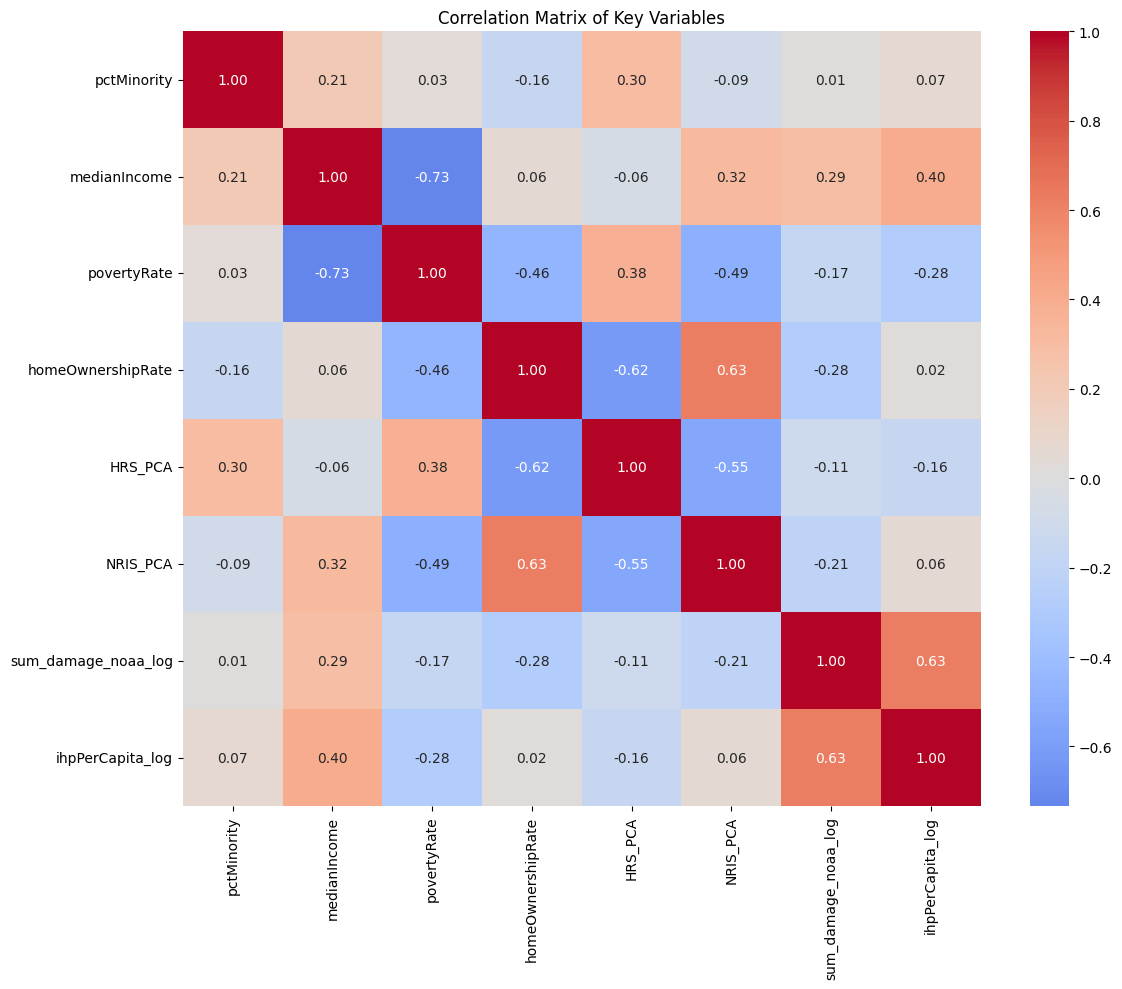

In [330]:
#Select variables for correlation analysis
corr_vars = [
    'pctMinority', 'medianIncome', 'povertyRate', 'homeOwnershipRate',
    'HRS_PCA', 'NRIS_PCA', 'sum_damage_noaa_log',
    'ihpPerCapita_log'
]

#Calculate correlation matrix
corr_matrix = county_df[corr_vars].corr()

#Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Key Variables')
plt.tight_layout()
plt.show()

### County clustering to identify patterns

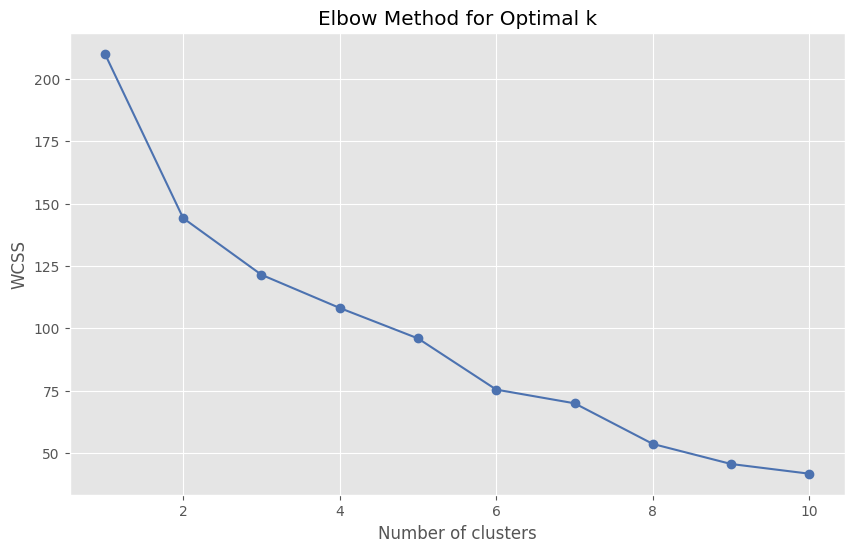

KeyError: 'Column not found: disparity_score'

In [393]:
#Variables for clustering
cluster_vars = ['pctMinority', 'medianIncome', 'povertyRate', 'HRS_PCA', 'NRIS_PCA', 'sum_damage_noaa_log']

#Scale variables for clustering
from sklearn.preprocessing import StandardScaler
X_cluster = StandardScaler().fit_transform(county_df[cluster_vars].dropna())

#Optimal number of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_cluster)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

#Clustering with optimal k (determined from plot)
kmeans = KMeans(n_clusters=4, random_state=42)
countydf = county_df.copy().dropna()
countydf['cluster'] = kmeans.fit_predict(X_cluster)

# #Analyze aid disparities by cluster
# disparity_by_cluster = countydf.groupby('cluster')['disparity_score'].mean().sort_values()
# plt.figure(figsize=(10, 6))
# disparity_by_cluster.plot(kind='bar')
# plt.title('Average Aid Disparity by County Cluster')
# plt.xlabel('Cluster')
# plt.ylabel('Average Disparity Score')
# plt.show()

# Modeling

## XGBoost

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split

features = [
    'medianIncome', 'pctMinority', 'povertyRate', 'homeOwnershipRate',
    'housing_vulnerability_score', 'total_damage_estimate', 'flood_depth'
]

X = merged_df[features]
y = merged_df['aid_per_capita']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


## SHAP

In [ ]:
import shap

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

# Disparity Score

In [ ]:
# Train model excluding socio-economic variables:
objective_features = ['total_damage_estimate', 'flood_depth', 'housing_vulnerability_score']
X_objective = merged_df[objective_features]

X_train_obj, X_test_obj, y_train_obj, y_test_obj = train_test_split(
    X_objective, y, test_size=0.2, random_state=42)

model_objective = xgb.XGBRegressor(random_state=42)
model_objective.fit(X_train_obj, y_train_obj)

merged_df['expected_aid'] = model_objective.predict(X_objective)

# Disparity Score calculation:
merged_df['disparity_score'] = (merged_df['aid_per_capita'] - merged_df['expected_aid']) / merged_df['expected_aid']


# Geospatial Analysis

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load Texas county shapefile
counties_gdf = gpd.read_file('tx_counties.shp')
counties_gdf['county'] = counties_gdf['county'].str.lower()

geo_df = counties_gdf.merge(merged_df, on='county')

fig, ax = plt.subplots(figsize=(12,8))
geo_df.plot(column='disparity_score', cmap='RdYlGn', legend=True, ax=ax)
ax.set_title('FEMA Aid Disparity Score by Texas County')
plt.show()

# Hypothesis Testing & Validation

In [ ]:
import statsmodels.api as sm

X_sm = sm.add_constant(X)
model_sm = sm.OLS(y, X_sm).fit()
print(model_sm.summary())

1. OpenFEMA Dataset: Housing Assistance Program Data - Owners - v2 https://www.fema.gov/openfema-data-page/housing-assistance-program-data-owners-v2

2. OpenFEMA Dataset: Housing Assistance Program Data - Renters - v2 https://www.fema.gov/openfema-data-page/housing-assistance-program-data-renters-v2

3. OpenFEMA Dataset: Registration Intake and Individuals Household Program (RI-IHP) - v2 https://www.fema.gov/openfema-data-page/registration-intake-and-individuals-household-program-ri-ihp-v2

4. OpenFEMA Dataset: Individuals and Households Program - Valid Registrations - v1 https://www.fema.gov/openfema-data-page/individuals-and-households-program-valid-registrations-v1

5. OpenFEMA Dataset: Individual Assistance Housing Registrants - Large Disasters - v1 https://www.fema.gov/openfema-data-page/individual-assistance-housing-registrants-large-disasters-v1

6. CENSUS dashboard https://data.census.gov/table?g=040XX00US48

7. CENSUS data API https://api.census.gov/data/2017/acs/acs5/variables.html


8. NOAA Hurricane Damage Data https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/

9. The National Risk Index https://hazards.fema.gov/nri/data-resources

10. U.S. Department of Housing and Urban Development (HUD) Comprehensive Housing Affordability Strategy data https://www.huduser.gov/portal/datasets/cp.html

11. ACS 5YR Housing Estimate Data by County https://hudgis-hud.opendata.arcgis.com/datasets/fb3a36d3f1364350becadb5c2e12fd71/about

12. Public Housing Physical Inspection Scores 2016 https://www.huduser.gov/portal/datasets/pis.html#data_2016